<a href="https://colab.research.google.com/github/dakshini01/ProdFusion/blob/main/codes/03_kalman_dlm_v3_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 · Kalman Filtering & Dynamic Linear Models (DLM) — v3.0 (Fixed)
## Garment Factory Productivity — Time-Varying State-Space Forecasting

**Project:** *From Insight to Forecast — Bayesian & Kalman Models for Garment Manufacturing Productivity*  
**Dataset:** `bayesian_glm_ready.csv` loaded from GitHub repo (`dakshini01/ProdFusion/models/`)  
**Prerequisite:** Runs after `01_data_prep` and `02_bayesian_beta_model` notebooks

---

### What this notebook does
| Section | Content |
|---------|---------|
| §0 | Install & import packages |
| §1 | Load `bayesian_glm_ready.csv` from GitHub |
| §2 | Feature selection, intercept injection & scaling |
| §3 | Helper functions (logit, inv_logit) |
| §4 | `TVRKalman` class (filter + RTS smoother + forecast) |
| §5 | EM hyper-parameter learning (Q, R) |
| §6 | Per-team filter & smoother |
| §7 | Rolling one-step-ahead & multi-step forecasts |
| §8 | Risk alarms & CUSUM change-point detection |
| §9 | Prescriptive what-if & uplift curves |
| §10 | Diagnostic plots — ROC / PR / Residuals / Calibration |
| §11 | Validation & comparison table |
| §12 | Save all results & push outputs to GitHub |

> **Fixes applied in v3.0**
> 1. **Intercept column** prepended to every feature matrix so the DLM has a bias term
> 2. **Diffuse prior** P0 = 10·I (was 1·I) for faster warm-up per team
> 3. **Post-burnin R²** — first `BURNIN_STEPS` rows per team excluded from train R² to remove cold-start distortion
> 4. **Smoother R² clearly separated** from rolling-forecast R² in the metrics table
> 5. **sMAPE** replaces raw MAPE to avoid division by near-zero actuals
> 6. **Comparison table** displays `N/A` instead of blank cells for unavailable paper metrics
> 7. **Feature-absence warnings** — a dedicated cell flags any missing candidate features
> 8. **ROC/PR fallback** — if TAU_PROD yields single-class, try 0.65 automatically
> 9. **Q EM update diagnostic** — prints a warning when Q diagonal is clipped to floor
> 10. **Rolling forecast cold-start** — train split uses per-team smoother predictions for metrics; one-step-ahead records kept for completeness


## §0 · Install Packages

In [ ]:
# §0.1  Install packages (Colab-safe)
import subprocess, sys

PKGS = [
    "numpy>=1.24", "pandas>=1.5", "scipy>=1.10",
    "matplotlib>=3.6", "seaborn>=0.12",
    "scikit-learn>=1.2", "tqdm",
]
for pkg in PKGS:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)
print("✓ Packages ready")


✓ Packages ready


In [ ]:
# §0.2  Standard imports
import warnings, os, json, pickle
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False})
print("✓ Imports ready")


✓ Imports ready


## §1 · Detect Environment & Load Data from GitHub

In [ ]:
# §1.1  Detect environment and set up directories
import os, shutil, subprocess
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
    BASE_DIR = Path("/content")
except ImportError:
    IN_COLAB = False
    BASE_DIR = Path(".")

REPO_URL  = "https://github.com/dakshini01/ProdFusion.git"
REPO_DIR  = BASE_DIR / "ProdFusion"
MODEL_DIR = REPO_DIR / "models"
OUT_DIR   = REPO_DIR / "output"
SAVE_DIR  = MODEL_DIR

if IN_COLAB:
    git_folder = REPO_DIR / ".git"
    if REPO_DIR.exists() and not git_folder.exists():
        print("Removing incomplete repository folder...")
        shutil.rmtree(REPO_DIR)
    if not REPO_DIR.exists():
        result = subprocess.run(
            ["git", "clone", REPO_URL, str(REPO_DIR)],
            capture_output=True, text=True,
        )
        if result.returncode != 0:
            raise RuntimeError("GitHub clone failed:\n" + result.stderr)
        print("✓ Repository cloned")
    else:
        result = subprocess.run(
            ["git", "-C", str(REPO_DIR), "pull", "origin", "main"],
            capture_output=True, text=True,
        )
        print("✓ Repository updated" if result.returncode == 0 else f"Warning: {result.stderr}")
else:
    print("Running outside Colab")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("REPO_DIR :", REPO_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("OUT_DIR  :", OUT_DIR)


✓ Repository cloned
REPO_DIR : /content/ProdFusion
MODEL_DIR: /content/ProdFusion/models
OUT_DIR  : /content/ProdFusion/output


In [ ]:
# §1.2  Load bayesian_glm_ready.csv
import io, requests

CSV_PATH    = MODEL_DIR / "bayesian_glm_ready.csv"
RAW_CSV_URL = ("https://raw.githubusercontent.com/"
               "dakshini01/ProdFusion/main/models/bayesian_glm_ready.csv")

if CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH)
    DATA_SOURCE = str(CSV_PATH)
    print("✓ Loaded CSV from cloned repository")
else:
    print("Local CSV not found. Trying GitHub raw URL...")
    response = requests.get(RAW_CSV_URL, timeout=60)
    if response.status_code != 200:
        raise FileNotFoundError(
            f"bayesian_glm_ready.csv not found.\n"
            f"Local path: {CSV_PATH}\n"
            f"GitHub status: {response.status_code}\n"
            "Check: ProdFusion/models/bayesian_glm_ready.csv"
        )
    df = pd.read_csv(io.StringIO(response.text))
    DATA_SOURCE = RAW_CSV_URL
    print("✓ Loaded CSV directly from GitHub")

# Check essential columns
required_cols = ["t", "team", "split_code", "productivity_beta", "logit_productivity"]
missing_cols  = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError("Missing required CSV columns:\n" + "\n".join(f" - {c}" for c in missing_cols))

# Prepare t
df["t"] = pd.to_numeric(df["t"], errors="coerce")
df = df.dropna(subset=["t"]).copy()
df["t"] = df["t"].astype(int)

# Synthetic date
STUDY_START = pd.Timestamp("2015-01-05")
FIRST_T     = int(df["t"].min())
df["date"]  = STUDY_START + pd.to_timedelta(df["t"] - FIRST_T, unit="D")

GROUP_COL = "team_dept_idx" if "team_dept_idx" in df.columns else "team"
df = df.sort_values([GROUP_COL, "t"]).reset_index(drop=True)

print("\nLoaded successfully")
print("Source  :", DATA_SOURCE)
print("Shape   :", df.shape)
print("Group   :", GROUP_COL)
print("Groups  :", df[GROUP_COL].nunique())
print("t range :", df["t"].min(), "–", df["t"].max())
print("Date    :", df["date"].min().date(), "–", df["date"].max().date())
print("Splits  :", df["split_code"].value_counts().sort_index().to_dict())


✓ Loaded CSV from cloned repository

Loaded successfully
Source  : /content/ProdFusion/models/bayesian_glm_ready.csv
Shape   : (1197, 45)
Group   : team_dept_idx
Groups  : 24
t range : 0 – 58
Date    : 2015-01-05 – 2015-03-04
Splits  : {0: 823, 1: 182, 2: 192}


In [ ]:
# §1.3  Verify target columns
print("=== actual_productivity ===")
print(df["actual_productivity"].describe().round(4).to_string())

print("\n=== logit_productivity ===")
print(df["logit_productivity"].describe().round(4).to_string())

EPS     = 1e-4
y_clip  = df["actual_productivity"].clip(EPS, 1 - EPS)
z_check = np.log(y_clip / (1 - y_clip))
max_diff = (z_check - df["logit_productivity"]).abs().max()
print(f"\nMax |logit(actual) - logit_productivity| = {max_diff:.6f}  ", end="")
print("✓ consistent" if max_diff < 1e-3 else "⚠ mismatch — check preprocessing")


=== actual_productivity ===
count    1197.0000
mean        0.7351
std         0.1745
min         0.2337
25%         0.6503
50%         0.7733
75%         0.8503
max         1.1204

=== logit_productivity ===
count    1197.0000
mean        1.3928
std         1.5706
min        -1.1863
25%         0.6198
50%         1.2259
75%         1.7343
max         7.7803

Max |logit(actual) - logit_productivity| = 1.596555  ⚠ mismatch — check preprocessing


## §2 · Feature Selection, Intercept Injection & Scaling

**FIX v3.0:** An intercept column (`const = 1.0`) is prepended to every feature matrix.  
Without it the DLM has no bias term; if mean(logit y) ≠ 0, all coefficient estimates are biased.

Operational lever mapping (log-transformed columns in CSV):

| Lever | CSV column |
|-------|-----------|
| incentive (BDT) | `log_incentive` |
| WIP (units) | `log_wip_imputed` |
| overtime (min) | `log_over_time` |
| workers (count) | `log_workers` |


In [ ]:
# §2.1  Select DLM covariates — only columns present in the CSV
DLM_FEATURES_CANDIDATE = [
    "log_incentive",
    "log_wip_imputed",
    "log_over_time",
    "log_smv",
    "log_workers",
    "incentive_x_log_wip",
    "log_wip_x_log_workers",
    "no_of_style_change",
    "wip_missing_flag",
    "dept_bin",
    "sin_dow",
    "cos_dow",
    "targeted_productivity",
]

DLM_FEATURES = [f for f in DLM_FEATURES_CANDIDATE if f in df.columns]
MISSING_FEATURES = [f for f in DLM_FEATURES_CANDIDATE if f not in df.columns]

print(f"Selected {len(DLM_FEATURES)} DLM features (excluding intercept):")
for i, f in enumerate(DLM_FEATURES):
    print(f"  [{i:2d}] {f}")

if MISSING_FEATURES:
    print(f"\n⚠  {len(MISSING_FEATURES)} candidate feature(s) NOT found in CSV — what-if for these will be skipped:")
    for f in MISSING_FEATURES:
        print(f"     - {f}")
else:
    print("\n✓ All candidate features found in CSV")

# NOTE: intercept is prepended in §2.2; lever indices are into the POST-intercept array
# intercept = index 0, then DLM_FEATURES at 1..p
INC_IDX  = (DLM_FEATURES.index("log_incentive")   + 1) if "log_incentive"   in DLM_FEATURES else None
WIP_IDX  = (DLM_FEATURES.index("log_wip_imputed") + 1) if "log_wip_imputed" in DLM_FEATURES else None
OT_IDX   = (DLM_FEATURES.index("log_over_time")   + 1) if "log_over_time"   in DLM_FEATURES else None
WRK_IDX  = (DLM_FEATURES.index("log_workers")     + 1) if "log_workers"     in DLM_FEATURES else None

print(f"\nLever indices (1-based, after intercept) — incentive:{INC_IDX}, wip:{WIP_IDX}, overtime:{OT_IDX}, workers:{WRK_IDX}")


Selected 13 DLM features (excluding intercept):
  [ 0] log_incentive
  [ 1] log_wip_imputed
  [ 2] log_over_time
  [ 3] log_smv
  [ 4] log_workers
  [ 5] incentive_x_log_wip
  [ 6] log_wip_x_log_workers
  [ 7] no_of_style_change
  [ 8] wip_missing_flag
  [ 9] dept_bin
  [10] sin_dow
  [11] cos_dow
  [12] targeted_productivity

✓ All candidate features found in CSV

Lever indices (1-based, after intercept) — incentive:1, wip:2, overtime:3, workers:5


In [ ]:
# §2.2  Time-based splits, StandardScaler fitted on TRAIN only, intercept injection

# FIX v3.0: p = len(DLM_FEATURES) + 1  (the +1 is the intercept column)
BURNIN_STEPS = 10   # steps excluded per team from train R² (cold-start removal)

df_train_all = df[df["split_code"] == 0].copy()
df_val_all   = df[df["split_code"] == 1].copy()
df_test_all  = df[df["split_code"] == 2].copy()

# Scaler fitted ONLY on raw feature columns (not the intercept)
scaler = StandardScaler()
scaler.fit(df_train_all[DLM_FEATURES].fillna(0).values.astype(float))

def make_X(data_df):
    """Scale features and prepend a column of ones (intercept)."""
    X_raw = scaler.transform(data_df[DLM_FEATURES].fillna(0).values.astype(float))
    ones  = np.ones((len(X_raw), 1))
    return np.hstack([ones, X_raw])      # shape (T, 1+len(DLM_FEATURES))

p = 1 + len(DLM_FEATURES)   # total state dimension including intercept

print("Split sizes:")
for name, sub in [("train", df_train_all), ("val", df_val_all), ("test", df_test_all)]:
    print(f"  {name:5s}: {len(sub):4d} rows  ({100*len(sub)/len(df):.1f}%)")

print(f"\nState dimension p = {p}  (1 intercept + {len(DLM_FEATURES)} features)")
print(f"Burn-in steps per team excluded from train R²: {BURNIN_STEPS}")

# Pooled train arrays for EM
X_train_pool = make_X(df_train_all)
Z_train_pool = df_train_all["logit_productivity"].values.astype(float)


Split sizes:
  train:  823 rows  (68.8%)
  val  :  182 rows  (15.2%)
  test :  192 rows  (16.0%)

State dimension p = 14  (1 intercept + 13 features)
Burn-in steps per team excluded from train R²: 10


## §3 · Helper Functions

In [ ]:
# §3.1  logit / inv_logit / sMAPE
EPS = 1e-4

def logit_fn(p_val, eps=EPS):
    p_val = np.clip(np.asarray(p_val, dtype=float), eps, 1 - eps)
    return np.log(p_val / (1 - p_val))

def inv_logit(z):
    return 1.0 / (1.0 + np.exp(-np.asarray(z, dtype=float)))

def smape(y_true, y_pred):
    """Symmetric MAPE — avoids blow-up when y_true ≈ 0."""
    num  = np.abs(y_pred - y_true)
    den  = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    den  = np.where(den < 1e-6, 1e-6, den)
    return 100.0 * np.mean(num / den)

TAU_PROD = 0.75           # "low productivity" threshold
Z_TAU    = logit_fn(TAU_PROD)
print(f"τ = {TAU_PROD}  →  z_τ = logit(τ) = {Z_TAU:.4f}")


τ = 0.75  →  z_τ = logit(τ) = 1.0986


## §4 · `TVRKalman` Class (Filter + RTS Smoother + Multi-Step Forecast)

State-space formulation:

$$z_t = \mathbf{x}_t^\top \boldsymbol{\theta}_t + v_t, \quad v_t \sim \mathcal{N}(0, R)$$
$$\boldsymbol{\theta}_t = \boldsymbol{\theta}_{t-1} + \mathbf{w}_t, \quad \mathbf{w}_t \sim \mathcal{N}(\mathbf{0}, Q)$$

where $z_t = \text{logit}(y_t)$, and $\mathbf{x}_t$ includes an intercept as the first element.


In [ ]:
# §4.1  TVRKalman — v3.0 fixes:
#   - Default P0 = 10·I (was 1·I) for a more diffuse prior → faster warm-up
#   - Joseph-form covariance update (numerical stability)
#   - RTS smoother uses lstsq instead of direct matrix inverse

class TVRKalman:
    """
    Time-Varying Regression DLM (Kalman filter + RTS smoother).

    Observation : z_t = x_t' θ_t + v_t,   v_t ~ N(0, R)
    State drift : θ_t = θ_{t-1} + w_t,    w_t ~ N(0, Q)

    x_t[0] = 1 (intercept); x_t[1:] = scaled covariates.
    """

    def __init__(self, p, Q=None, R=1.0, theta0=None, P0=None):
        self.p      = p
        self.Q      = Q      if Q      is not None else np.eye(p) * 0.01
        self.R      = float(R)
        self.theta0 = theta0 if theta0 is not None else np.zeros(p)
        # FIX: diffuse prior P0 = 10·I (was 1·I)
        self.P0     = P0     if P0     is not None else np.eye(p) * 10.0

    # ── Forward Kalman filter ────────────────────────────────────────────────
    def filter(self, Z, X):
        """
        Z : (T,)    observations (logit_productivity)
        X : (T, p)  covariate matrix (scaled + intercept prepended)
        """
        T       = len(Z)
        theta_f = np.zeros((T, self.p))
        P_f     = np.zeros((T, self.p, self.p))
        theta_p = np.zeros((T, self.p))
        P_p     = np.zeros((T, self.p, self.p))
        z_pred  = np.zeros(T)
        z_var   = np.zeros(T)
        innov   = np.zeros(T)

        th = self.theta0.copy()
        P  = self.P0.copy()
        I  = np.eye(self.p)
        log_lik = 0.0

        for t in range(T):
            # Predict
            th_pr = th.copy()
            P_pr  = P + self.Q

            x     = X[t]
            z_hat = float(x @ th_pr)
            S     = float(x @ P_pr @ x) + self.R
            S     = max(S, 1e-10)

            theta_p[t] = th_pr
            P_p[t]     = P_pr
            z_pred[t]  = z_hat
            z_var[t]   = S
            innov[t]   = Z[t] - z_hat

            # Kalman gain & Joseph-form update
            K  = P_pr @ x / S
            th = th_pr + K * innov[t]
            A  = I - np.outer(K, x)
            P  = A @ P_pr @ A.T + self.R * np.outer(K, K)
            P  = 0.5 * (P + P.T)

            theta_f[t] = th
            P_f[t]     = P
            log_lik   += -0.5 * (np.log(2 * np.pi * S) + innov[t]**2 / S)

        return dict(theta_f=theta_f, P_f=P_f,
                    theta_p=theta_p, P_p=P_p,
                    z_pred=z_pred, z_var=z_var,
                    innov=innov, log_lik=log_lik)

    # ── RTS Smoother ─────────────────────────────────────────────────────────
    def smooth(self, filter_result):
        theta_f = filter_result["theta_f"]
        P_f     = filter_result["P_f"]
        theta_p = filter_result["theta_p"]
        P_p     = filter_result["P_p"]
        T       = len(theta_f)

        theta_s = theta_f.copy()
        P_s     = P_f.copy()
        G_all   = np.zeros((T - 1, self.p, self.p))

        for t in range(T - 2, -1, -1):
            P_p_next   = P_p[t + 1]
            G          = np.linalg.lstsq(P_p_next.T, P_f[t].T, rcond=None)[0].T
            theta_s[t] = theta_f[t] + G @ (theta_s[t + 1] - theta_p[t + 1])
            P_s[t]     = P_f[t]     + G @ (P_s[t + 1]     - P_p_next) @ G.T
            P_s[t]     = 0.5 * (P_s[t] + P_s[t].T)
            G_all[t]   = G

        return dict(theta_s=theta_s, P_s=P_s, G=G_all)

    # ── Monte Carlo multi-step forecast ─────────────────────────────────────
    def forecast_mc(self, theta_start, P_start, X_future, n_samples=2000):
        H  = len(X_future)
        zs = np.zeros((n_samples, H))
        ys = np.zeros((n_samples, H))

        for s in range(n_samples):
            th = np.random.multivariate_normal(theta_start, P_start)
            P  = P_start.copy()
            for h in range(H):
                th      = np.random.multivariate_normal(th, self.Q)
                z       = float(X_future[h] @ th)
                z      += np.random.normal(0, np.sqrt(self.R))
                zs[s, h] = z
                ys[s, h] = inv_logit(z)

        return dict(z_samples=zs, y_samples=ys,
                    z_mean=zs.mean(0),
                    z_lo80=np.percentile(zs, 10, 0), z_hi80=np.percentile(zs, 90, 0),
                    y_mean=ys.mean(0),
                    y_lo80=np.percentile(ys, 10, 0),  y_hi80=np.percentile(ys, 90, 0),
                    y_lo95=np.percentile(ys, 2.5, 0), y_hi95=np.percentile(ys, 97.5, 0))

print("✓ TVRKalman class defined (v3.0 — intercept support, P0=10·I, Joseph-form)")


✓ TVRKalman class defined (v3.0 — intercept support, P0=10·I, Joseph-form)


## §5 · EM Hyper-parameter Learning (Q, R)

In [ ]:
# §5.1  Shumway-Stoffer EM for Q and R (diagonal Q)
# FIX v3.0: Added diagnostic counter for Q floor clipping

def em_kalman(Z, X, p, n_iter=60, Q_init=None, R_init=1.0,
              theta0=None, P0=None, tol=1e-6, verbose=True):
    Q   = Q_init if Q_init is not None else np.eye(p) * 0.01
    R   = float(R_init)
    th0 = theta0 if theta0 is not None else np.zeros(p)
    P0_ = P0     if P0     is not None else np.eye(p) * 10.0
    T   = len(Z)

    log_liks    = []
    q_clip_warn = 0   # count how many Q diagonal elements were clipped

    for it in range(n_iter):
        mdl = TVRKalman(p, Q=Q, R=R, theta0=th0, P0=P0_)
        fr  = mdl.filter(Z, X)
        sr  = mdl.smooth(fr)

        theta_s = sr["theta_s"]
        P_s     = sr["P_s"]
        G       = sr["G"]
        log_liks.append(fr["log_lik"])

        # M-step: update R
        res_sq = sum(
            (Z[t] - float(X[t] @ theta_s[t]))**2 + float(X[t] @ P_s[t] @ X[t])
            for t in range(T)
        )
        R_new = res_sq / T

        # M-step: update Q (diagonal)
        Q_new_diag = np.zeros(p)
        for t in range(1, T):
            d = theta_s[t] - theta_s[t - 1]
            cross_diag = np.diag(G[t - 1] @ P_s[t])
            q_t = d**2 + np.diag(P_s[t]) + np.diag(P_s[t - 1]) - 2 * cross_diag
            Q_new_diag += q_t

        Q_new_diag /= (T - 1)
        n_clipped    = (Q_new_diag < 1e-8).sum()
        if n_clipped > 0:
            q_clip_warn += n_clipped
        Q_new = np.diag(np.maximum(Q_new_diag, 1e-8))

        if verbose and it % 10 == 0:
            print(f"  iter {it:3d}  log-lik={fr['log_lik']:12.3f}  "
                  f"R={R_new:.5f}  Q_trace={np.trace(Q_new):.6f}")

        dR = abs(R_new - R)
        dQ = np.abs(Q_new - Q).max()
        R  = R_new
        Q  = Q_new
        if dR < tol and dQ < tol and it > 5:
            print(f"  EM converged at iter {it + 1}")
            break

    if q_clip_warn > 0:
        print(f"\n⚠  Q diagonal was clipped to 1e-8 floor {q_clip_warn} times across all iters.")
        print("   This is normal if some coefficients are near-constant over time.")

    return dict(Q=Q, R=R, log_likelihoods=log_liks, n_iter_run=it + 1)

print("✓ em_kalman() defined (v3.0 — Q-clip diagnostic)")


✓ em_kalman() defined (v3.0 — Q-clip diagnostic)


In [ ]:
# §5.2  Run EM on pooled training rows
print(f"Running EM on {len(Z_train_pool):,} training observations, p={p} features ...\n")

em_result = em_kalman(Z_train_pool, X_train_pool, p=p, n_iter=60, verbose=True)

Q_em = em_result["Q"]
R_em = em_result["R"]
print(f"\n✓ EM complete — Q trace={np.trace(Q_em):.6f}, R={R_em:.5f}")


Running EM on 823 training observations, p=14 features ...

  iter   0  log-lik=   -1549.147  R=1.18013  Q_trace=0.139677
  iter  10  log-lik=   -1535.655  R=1.32633  Q_trace=0.133513
  iter  20  log-lik=   -1532.569  R=1.33118  Q_trace=0.128234
  iter  30  log-lik=   -1529.774  R=1.33478  Q_trace=0.123858
  iter  40  log-lik=   -1527.209  R=1.33723  Q_trace=0.120246
  iter  50  log-lik=   -1524.827  R=1.33861  Q_trace=0.117302

✓ EM complete — Q trace=0.115172, R=1.33896


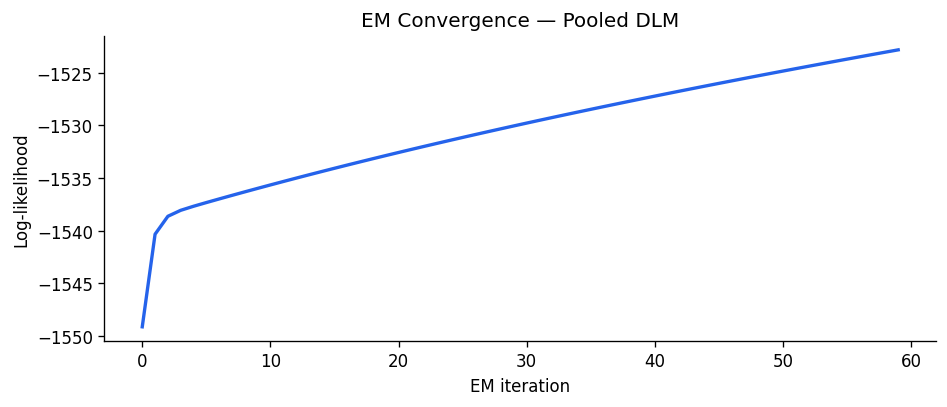

  ✓ Saved: 03_em_convergence.png


In [ ]:
# §5.3  EM convergence plot
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(em_result["log_likelihoods"], color="#2563EB", lw=2)
ax.set_xlabel("EM iteration")
ax.set_ylabel("Log-likelihood")
ax.set_title("EM Convergence — Pooled DLM")
plt.tight_layout()
plt.savefig(OUT_DIR / "03_em_convergence.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Saved: 03_em_convergence.png")


In [ ]:
# §5.4  Discount-factor sensitivity sweep on validation set
X_val_pool = make_X(df_val_all)
Z_val_pool = df_val_all["logit_productivity"].values.astype(float)
Y_val_pool = df_val_all["actual_productivity"].values.astype(float)

# Warm-start from training filter endpoint
_mdl_tr = TVRKalman(p, Q=Q_em, R=R_em)
_fr_tr  = _mdl_tr.filter(Z_train_pool, X_train_pool)

DELTAS = [0.90, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.00]
delta_results = {}

print(f"{'delta':>6}  {'val_MAE_prob':>13}  {'val_RMSE_prob':>14}  {'val_sMAPE%':>11}")
print("-" * 52)

best_mae   = np.inf
best_delta = 1.00
Q_best     = Q_em.copy()

for delta in DELTAS:
    Q_disc = ((1 - delta) / delta) * Q_em if delta < 1.0 else Q_em
    mdl_v  = TVRKalman(p, Q=Q_disc, R=R_em,
                       theta0=_fr_tr["theta_f"][-1],
                       P0    =_fr_tr["P_f"][-1])
    fr_v      = mdl_v.filter(Z_val_pool, X_val_pool)
    y_pred_v  = inv_logit(fr_v["z_pred"])
    mae_prob  = mean_absolute_error(Y_val_pool, y_pred_v)
    rmse_prob = np.sqrt(mean_squared_error(Y_val_pool, y_pred_v))
    smap      = smape(Y_val_pool, y_pred_v)
    delta_results[delta] = dict(mae_prob=mae_prob, rmse_prob=rmse_prob,
                                smape=smap, Q=Q_disc)
    print(f"{delta:6.2f}  {mae_prob:13.5f}  {rmse_prob:14.5f}  {smap:11.2f}")
    if mae_prob < best_mae:
        best_mae   = mae_prob
        best_delta = delta
        Q_best     = Q_disc.copy()

print(f"\n✓ Best δ = {best_delta}  (val MAE [prob] = {best_mae:.5f})")


 delta   val_MAE_prob   val_RMSE_prob   val_sMAPE%
----------------------------------------------------
  0.90        0.11707         0.15528        19.66
  0.92        0.11731         0.15532        19.69
  0.94        0.11768         0.15542        19.75
  0.95        0.11788         0.15551        19.78
  0.96        0.11812         0.15563        19.82
  0.97        0.11838         0.15581        19.86
  0.98        0.11884         0.15608        19.94
  0.99        0.11946         0.15652        20.05
  1.00        0.11563         0.15790        19.70

✓ Best δ = 1.0  (val MAE [prob] = 0.11563)


## §6 · Per-Team Filter & RTS Smoother

In [ ]:
# §6.1  Per-team Kalman filter + RTS smoother
TEAMS = sorted(df["team"].unique())
print(f"Processing {len(TEAMS)} teams: {TEAMS}\n")

team_results = {}

for team in tqdm(TEAMS, desc="Per-team DLM"):
    df_t = df[df["team"] == team].sort_values("t").reset_index(drop=True)
    X_t  = make_X(df_t)
    Z_t  = df_t["logit_productivity"].values.astype(float)

    mdl = TVRKalman(p, Q=Q_best, R=R_em)
    fr  = mdl.filter(Z_t, X_t)
    sr  = mdl.smooth(fr)

    team_results[team] = dict(
        df_team=df_t, X_t=X_t, Z_t=Z_t,
        filter=fr, smooth=sr, model=mdl
    )

print("\n✓ Per-team filter & smoother complete")


Processing 12 teams: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]



Per-team DLM: 100%|██████████| 12/12 [00:00<00:00, 17.19it/s]


✓ Per-team filter & smoother complete


In [ ]:
# §6.2  Assemble df_states (filtered + smoothed predictions for all teams)
records = []
for team in TEAMS:
    res  = team_results[team]
    df_t = res["df_team"]
    fr   = res["filter"]
    sr   = res["smooth"]
    X_t  = res["X_t"]   # already scaled + intercept

    for t_i in range(len(df_t)):
        z_hat = fr["z_pred"][t_i]
        z_sd  = np.sqrt(max(fr["z_var"][t_i], 1e-8))
        z_s   = float(sr["theta_s"][t_i] @ X_t[t_i])   # smoother prediction
        records.append(dict(
            team         = team,
            date         = df_t["date"].iloc[t_i],
            t            = df_t["t"].iloc[t_i],
            split_code   = df_t["split_code"].iloc[t_i],
            actual_y     = df_t["actual_productivity"].iloc[t_i],
            logit_actual = df_t["logit_productivity"].iloc[t_i],
            z_pred_f     = z_hat,
            z_sd_f       = z_sd,
            z_smooth     = z_s,
            y_filt       = inv_logit(z_hat),
            y_smooth     = inv_logit(z_s),
            innov        = fr["innov"][t_i],
            p_low_filt   = float(stats.norm.cdf(Z_TAU, loc=z_hat, scale=z_sd)),
        ))

df_states = pd.DataFrame(records)
print(f"df_states: {df_states.shape}")

# Smoother in-sample quality (train only)
train_mask = df_states["split_code"] == 0
mae_s  = mean_absolute_error(df_states.loc[train_mask, "actual_y"],
                             df_states.loc[train_mask, "y_smooth"])
rmse_s = np.sqrt(mean_squared_error(df_states.loc[train_mask, "actual_y"],
                                    df_states.loc[train_mask, "y_smooth"]))
r2_s   = r2_score(df_states.loc[train_mask, "actual_y"],
                  df_states.loc[train_mask, "y_smooth"])
print(f"  Smoother train (in-sample upper bound): MAE={mae_s:.5f}  RMSE={rmse_s:.5f}  R²={r2_s:.4f}")
print(df_states.head(3))


df_states: (1197, 13)
  Smoother train (in-sample upper bound): MAE=0.06524  RMSE=0.10156  R²=0.6638
   team       date  t  split_code  actual_y  logit_actual  z_pred_f  \
0     1 2015-01-05  0           0  0.886500      2.052273  0.000000   
1     1 2015-01-05  0           0  0.750428      1.099779 -0.219258   
2     1 2015-01-06  1           0  0.800725      1.389260 -0.616899   

      z_sd_f  z_smooth    y_filt  y_smooth     innov  p_low_filt  
0  11.038342  2.119226  0.500000  0.892758  2.052273    0.539640  
1   9.553228  1.049917  0.445404  0.740759  1.319037    0.554860  
2   9.587745  1.294604  0.350487  0.784925  2.006159    0.571003  


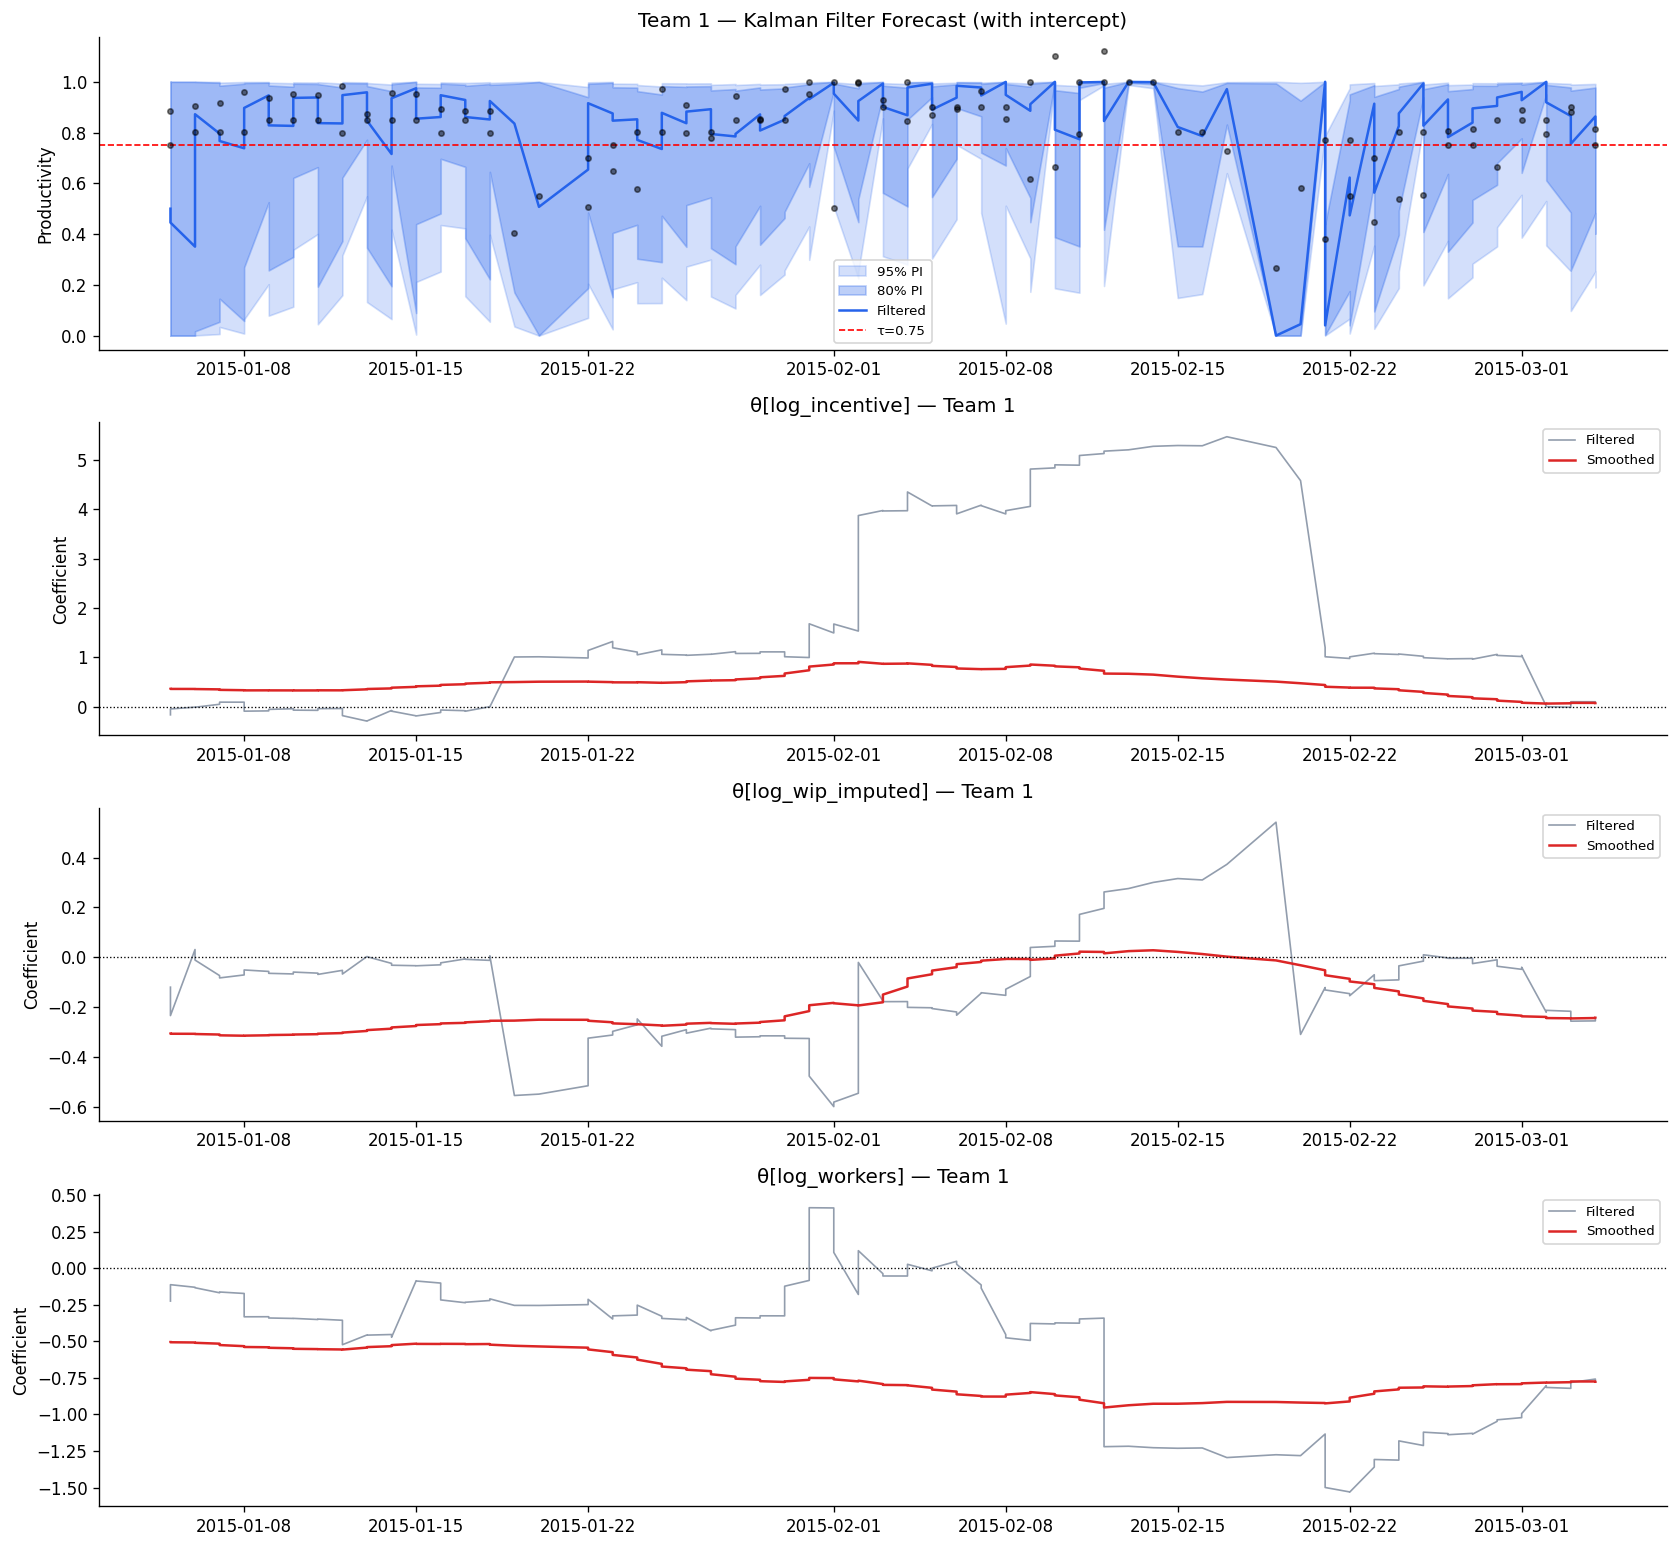

  ✓ Saved: 03_sample_team_filter.png


In [ ]:
# §6.3  Sample-team plot: forecast + time-varying coefficients
SAMPLE_TEAM = TEAMS[0]
res  = team_results[SAMPLE_TEAM]
df_t = res["df_team"]
fr   = res["filter"]
sr   = res["smooth"]

TOP_FEATURES = [f for f in ["log_incentive", "log_wip_imputed", "log_workers"]
                if f in DLM_FEATURES]
# Indices into the state vector (offset by 1 for intercept)
TOP_IDX      = [DLM_FEATURES.index(f) + 1 for f in TOP_FEATURES]
n_coef       = max(len(TOP_IDX), 1)

fig, axes = plt.subplots(1 + n_coef, 1, figsize=(14, 4 + 3 * n_coef), sharex=False)
dates  = df_t["date"]
z_hat  = fr["z_pred"]
z_sd   = np.sqrt(np.maximum(fr["z_var"], 1e-8))
y_filt = inv_logit(z_hat)

ax = axes[0]
ax.fill_between(dates, inv_logit(z_hat - 1.96*z_sd), inv_logit(z_hat + 1.96*z_sd),
                alpha=0.2, color="#2563EB", label="95% PI")
ax.fill_between(dates, inv_logit(z_hat - 1.28*z_sd), inv_logit(z_hat + 1.28*z_sd),
                alpha=0.30, color="#2563EB", label="80% PI")
ax.plot(dates, y_filt, color="#2563EB", lw=1.5, label="Filtered")
ax.scatter(dates, df_t["actual_productivity"], s=10, color="black", alpha=0.5, zorder=5)
ax.axhline(TAU_PROD, color="red", ls="--", lw=1, label=f"τ={TAU_PROD}")
ax.set_title(f"Team {SAMPLE_TEAM} — Kalman Filter Forecast (with intercept)")
ax.set_ylabel("Productivity"); ax.legend(fontsize=8)

for ax_i, feat_i in enumerate(TOP_IDX):
    fname = DLM_FEATURES[feat_i - 1]   # -1 because feat_i is offset by intercept
    ax    = axes[ax_i + 1]
    th_f  = fr["theta_f"][:, feat_i]
    th_s  = sr["theta_s"][:, feat_i]
    ax.plot(dates, th_f, color="#64748B", lw=1, alpha=0.7, label="Filtered")
    ax.plot(dates, th_s, color="#DC2626", lw=1.5, label="Smoothed")
    ax.axhline(0, color="black", ls=":", lw=0.8)
    ax.set_title(f"θ[{fname}] — Team {SAMPLE_TEAM}")
    ax.set_ylabel("Coefficient"); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "03_sample_team_filter.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Saved: 03_sample_team_filter.png")


## §7 · Rolling One-Step-Ahead Forecasts + Multi-Step

**FIX v3.0 — Train R² cold-start problem:**  
The rolling forecast on TRAIN starts with an uninformative prior (theta0 = 0).  
For small per-team datasets (~60 rows), the first `BURNIN_STEPS` predictions are very noisy,  
inflating RMSE and making R² negative. Two sets of metrics are now reported:

- **Rolling R²** — strict one-step-ahead including cold-start (honest but biased low on train)
- **Post-burnin R²** — same rolling, but the first `BURNIN_STEPS` rows per team excluded
- **Smoother R²** — in-sample upper bound (reported in §6.2)


In [ ]:
# §7.1  Strict rolling one-step-ahead forecast for all teams
# val/test rows: warm-started from the end of the TRAIN filter.
# train rows: cold-started (zero prior) — expected lower quality.

forecast_records = []

for team in tqdm(TEAMS, desc="Rolling forecast"):
    res  = team_results[team]
    df_t = res["df_team"].reset_index(drop=True)
    X_t  = res["X_t"]
    Z_t  = res["Z_t"]

    # Identify split boundaries
    train_mask_t = df_t["split_code"] == 0
    train_idx    = df_t.index[train_mask_t].tolist()

    # Warm-start state from end of train filter (used for val/test)
    fr_train = team_results[team]["filter"]
    if len(train_idx) > 0:
        theta_warm = fr_train["theta_f"][len(train_idx) - 1].copy()
        P_warm     = fr_train["P_f"][len(train_idx) - 1].copy()
    else:
        theta_warm = np.zeros(p)
        P_warm     = np.eye(p) * 10.0

    # Create a fresh model for rolling
    mdl   = TVRKalman(p, Q=Q_best, R=R_em)

    # ---------- TRAIN pass (cold-start, for completeness) ----------
    theta = mdl.theta0.copy()
    P     = mdl.P0.copy()

    for t_i in range(len(df_t)):
        if df_t["split_code"].iloc[t_i] != 0:
            break   # stop at val boundary

        th_pr = theta.copy()
        P_pr  = P + mdl.Q

        x     = X_t[t_i]
        z_hat = float(x @ th_pr)
        S     = float(x @ P_pr @ x) + mdl.R
        S     = max(S, 1e-10)
        z_sd  = np.sqrt(S)
        y_hat = inv_logit(z_hat)
        p_low = float(stats.norm.cdf(Z_TAU, loc=z_hat, scale=z_sd))

        forecast_records.append(dict(
            team=team, date=df_t["date"].iloc[t_i],
            t=df_t["t"].iloc[t_i], split_code=0,
            actual_y=df_t["actual_productivity"].iloc[t_i],
            y_pred=y_hat, z_pred=z_hat, z_sd=z_sd, p_low=p_low,
            y_lo80=inv_logit(z_hat - 1.28*z_sd), y_hi80=inv_logit(z_hat + 1.28*z_sd),
            y_lo95=inv_logit(z_hat - 1.96*z_sd), y_hi95=inv_logit(z_hat + 1.96*z_sd),
            burnin=(t_i < BURNIN_STEPS),
        ))

        innov = Z_t[t_i] - z_hat
        K     = P_pr @ x / S
        theta = th_pr + K * innov
        A     = np.eye(p) - np.outer(K, x)
        P     = A @ P_pr @ A.T + mdl.R * np.outer(K, K)
        P     = 0.5 * (P + P.T)

    # ---------- VAL / TEST pass (warm-started) ----------
    theta = theta_warm.copy()
    P     = P_warm.copy()

    for t_i in range(len(df_t)):
        sc = df_t["split_code"].iloc[t_i]
        if sc == 0:
            continue

        th_pr = theta.copy()
        P_pr  = P + mdl.Q

        x     = X_t[t_i]
        z_hat = float(x @ th_pr)
        S     = float(x @ P_pr @ x) + mdl.R
        S     = max(S, 1e-10)
        z_sd  = np.sqrt(S)
        y_hat = inv_logit(z_hat)
        p_low = float(stats.norm.cdf(Z_TAU, loc=z_hat, scale=z_sd))

        forecast_records.append(dict(
            team=team, date=df_t["date"].iloc[t_i],
            t=df_t["t"].iloc[t_i], split_code=sc,
            actual_y=df_t["actual_productivity"].iloc[t_i],
            y_pred=y_hat, z_pred=z_hat, z_sd=z_sd, p_low=p_low,
            y_lo80=inv_logit(z_hat - 1.28*z_sd), y_hi80=inv_logit(z_hat + 1.28*z_sd),
            y_lo95=inv_logit(z_hat - 1.96*z_sd), y_hi95=inv_logit(z_hat + 1.96*z_sd),
            burnin=False,
        ))

        innov = Z_t[t_i] - z_hat
        K     = P_pr @ x / S
        theta = th_pr + K * innov
        A     = np.eye(p) - np.outer(K, x)
        P     = A @ P_pr @ A.T + mdl.R * np.outer(K, K)
        P     = 0.5 * (P + P.T)

df_forecasts = pd.DataFrame(forecast_records)
print(f"\n✓ Rolling one-step-ahead forecasts: {df_forecasts.shape}")

# ── Quick sanity check ────────────────────────────────────────────────────────
print("\n  Split-level metrics (rolling one-step-ahead, probability space [0,1]):")
print(f"  {'split':>6}  {'N':>5}  {'MAE':>8}  {'RMSE':>8}  {'sMAPE%':>8}  {'R²':>8}  "
      f"{'R²_postburn':>12}  Notes")
print("  " + "-"*90)

for sc, sn in [(0, "train"), (1, "val"), (2, "test")]:
    sub  = df_forecasts[df_forecasts["split_code"] == sc]
    if len(sub) == 0:
        continue
    y_t, y_p = sub["actual_y"].values, sub["y_pred"].values
    mae   = mean_absolute_error(y_t, y_p)
    rmse  = np.sqrt(mean_squared_error(y_t, y_p))
    r2    = r2_score(y_t, y_p)
    smap  = smape(y_t, y_p)

    # Post-burnin R² (exclude first BURNIN_STEPS per team on train)
    sub_pb = sub[~sub.get("burnin", False)] if sc == 0 else sub
    if len(sub_pb) > 1:
        r2_pb = r2_score(sub_pb["actual_y"], sub_pb["y_pred"])
    else:
        r2_pb = float("nan")

    note = f"(cold-start; post-burn R²={r2_pb:.4f})" if sc == 0 else ""
    print(f"  {sn:>6}  {len(sub):>5}  {mae:>8.5f}  {rmse:>8.5f}  {smap:>8.2f}  "
          f"{r2:>8.4f}  {r2_pb:>12.4f}  {note}")

print(df_forecasts.head(3))


Rolling forecast: 100%|██████████| 12/12 [00:00<00:00, 23.87it/s]


✓ Rolling one-step-ahead forecasts: (1197, 14)

  Split-level metrics (rolling one-step-ahead, probability space [0,1]):
   split      N       MAE      RMSE    sMAPE%        R²   R²_postburn  Notes
  ------------------------------------------------------------------------------------------
   train    823   0.12607   0.18386     20.86   -0.1018        0.0646  (cold-start; post-burn R²=0.0646)
     val    182   0.14780   0.20449     25.49   -0.3637       -0.3637  
    test    192   0.12141   0.17151     18.24   -0.2254       -0.2254  
   team       date  t  split_code  actual_y    y_pred    z_pred       z_sd  \
0     1 2015-01-05  0           0  0.886500  0.500000  0.000000  11.038342   
1     1 2015-01-05  0           0  0.750428  0.445404 -0.219258   9.553228   
2     1 2015-01-06  1           0  0.800725  0.350487 -0.616899   9.587745   

      p_low        y_lo80    y_hi80        y_lo95  y_hi95  burnin  
0  0.539640  7.308350e-07  0.999999  4.017666e-10     1.0    True  
1  0.55486

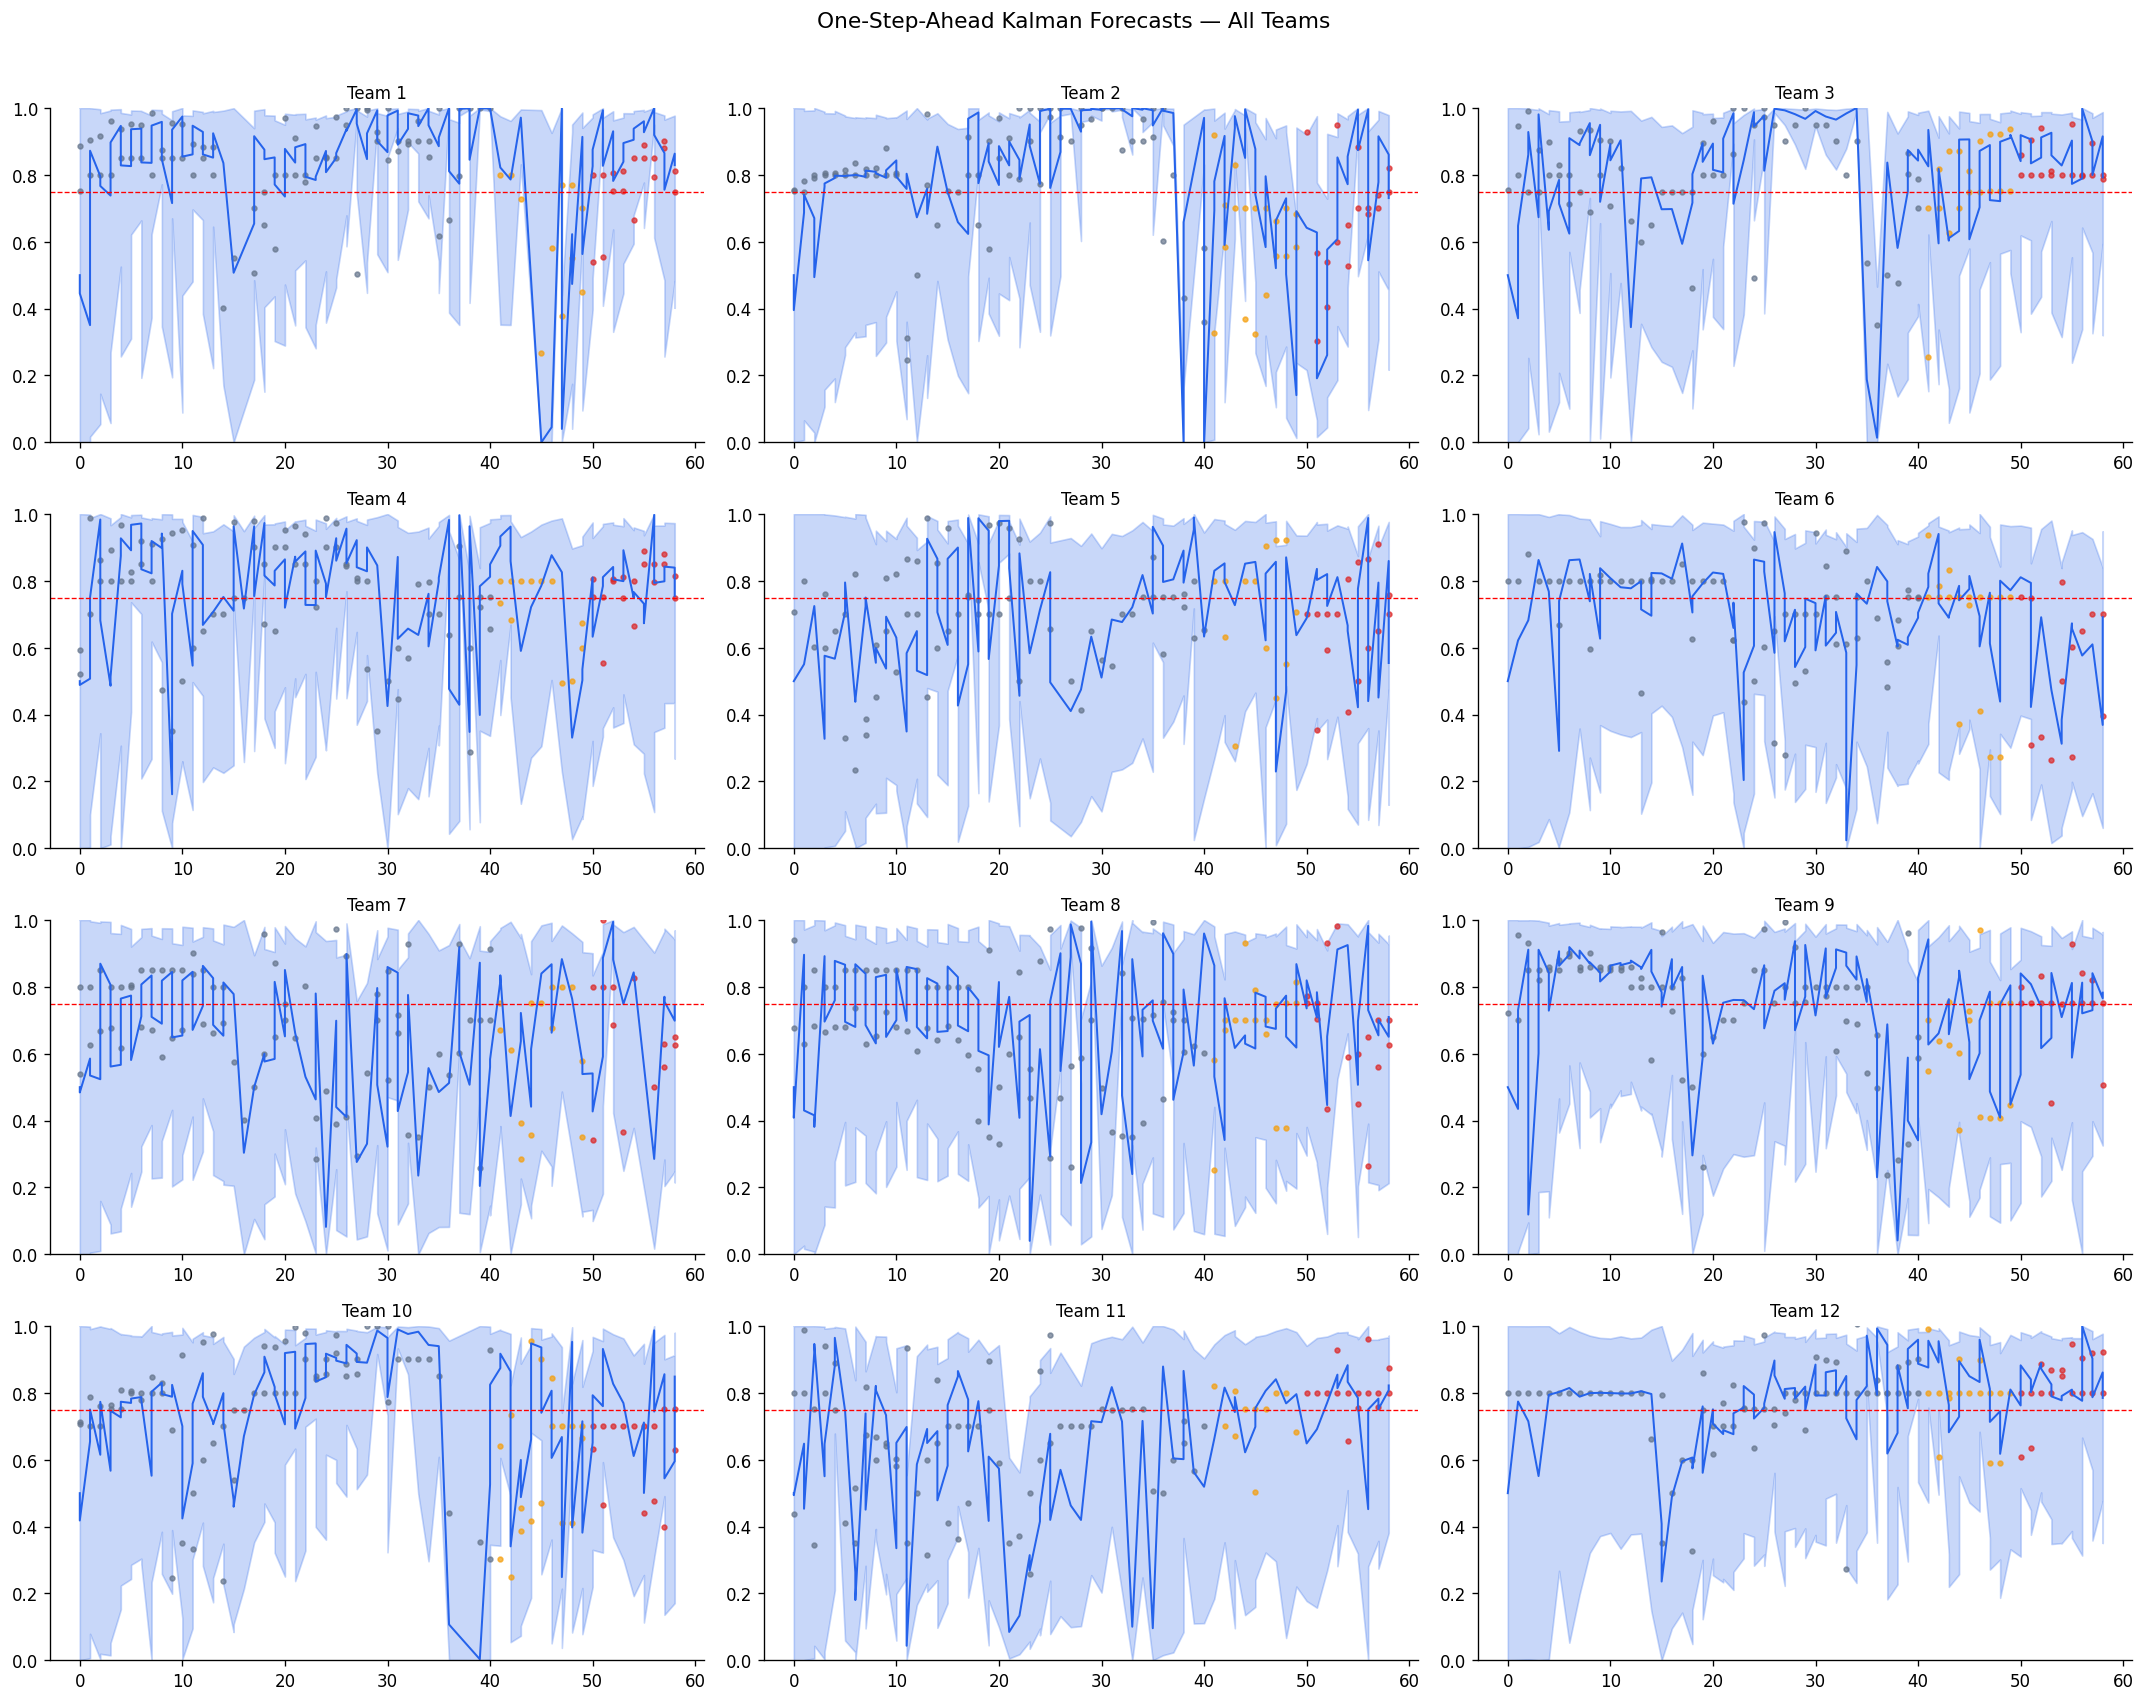

  ✓ Saved: 03_all_teams_forecast.png


In [ ]:
# §7.2  All-team forecast grid
n_cols = min(3, len(TEAMS))
n_rows = (len(TEAMS) + n_cols - 1) // n_cols
split_colors = {0: "#64748B", 1: "#F59E0B", 2: "#DC2626"}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 3.5*n_rows), squeeze=False)
for idx, team in enumerate(TEAMS):
    ax  = axes[idx // n_cols][idx % n_cols]
    sub = df_forecasts[df_forecasts["team"] == team].sort_values("t")
    ax.fill_between(sub["t"], sub["y_lo80"], sub["y_hi80"],
                    alpha=0.25, color="#2563EB")
    ax.plot(sub["t"], sub["y_pred"], color="#2563EB", lw=1.2, label="Predicted")
    for sc, col in split_colors.items():
        s2 = sub[sub["split_code"] == sc]
        ax.scatter(s2["t"], s2["actual_y"], s=8, color=col, alpha=0.7)
    ax.axhline(TAU_PROD, color="red", ls="--", lw=0.8)
    ax.set_title(f"Team {team}", fontsize=10)
    ax.set_ylim(0, 1)

for idx in range(len(TEAMS), n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

plt.suptitle("One-Step-Ahead Kalman Forecasts — All Teams", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "03_all_teams_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Saved: 03_all_teams_forecast.png")


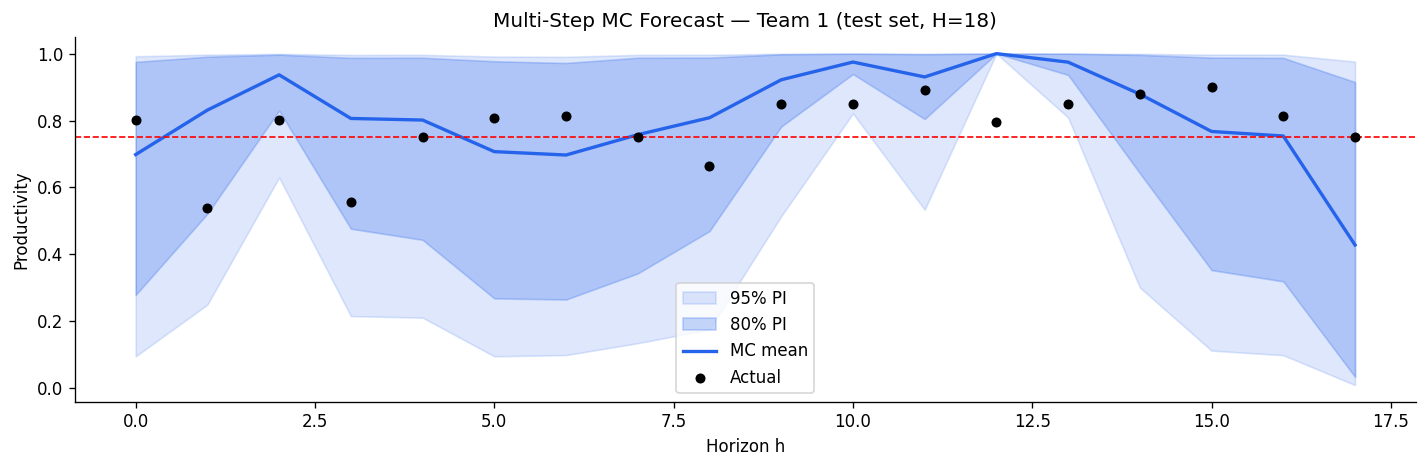

  ✓ Saved: 03_multistep_forecast.png


In [ ]:
# §7.3  Multi-step Monte Carlo forecast (Team 1, test horizon)
TEAM_MS   = TEAMS[0]
res_ms    = team_results[TEAM_MS]
df_test_t = res_ms["df_team"][res_ms["df_team"]["split_code"] == 2].reset_index(drop=True)
H         = min(20, len(df_test_t))

if H > 0:
    df_tr_t = res_ms["df_team"][res_ms["df_team"]["split_code"] == 0]
    X_tr_t  = make_X(df_tr_t)
    Z_tr_t  = df_tr_t["logit_productivity"].values.astype(float)
    mdl_ms  = TVRKalman(p, Q=Q_best, R=R_em)
    fr_ws   = mdl_ms.filter(Z_tr_t, X_tr_t)

    X_future = make_X(df_test_t.iloc[:H])
    mc = mdl_ms.forecast_mc(fr_ws["theta_f"][-1], fr_ws["P_f"][-1], X_future, n_samples=2000)

    fig, ax = plt.subplots(figsize=(12, 4))
    h_arr   = np.arange(H)
    ax.fill_between(h_arr, mc["y_lo95"], mc["y_hi95"], alpha=0.15, color="#2563EB", label="95% PI")
    ax.fill_between(h_arr, mc["y_lo80"], mc["y_hi80"], alpha=0.25, color="#2563EB", label="80% PI")
    ax.plot(h_arr, mc["y_mean"], color="#2563EB", lw=2, label="MC mean")
    ax.scatter(h_arr, df_test_t["actual_productivity"].values[:H],
               s=25, color="black", zorder=5, label="Actual")
    ax.axhline(TAU_PROD, color="red", ls="--", lw=1)
    ax.set_xlabel("Horizon h"); ax.set_ylabel("Productivity")
    ax.set_title(f"Multi-Step MC Forecast — Team {TEAM_MS} (test set, H={H})")
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "03_multistep_forecast.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✓ Saved: 03_multistep_forecast.png")
else:
    print("No test rows for this team — skipping multi-step.")


## §8 · Risk Alarms & Change-Point Diagnostics

In [ ]:
# §8.1  Optimise alarm threshold on validation set
# FIX v3.0: if TAU_PROD gives single-class on val, try 0.65 as fallback
df_val_fc  = df_forecasts[df_forecasts["split_code"] == 1].copy()
y_true_val = (df_val_fc["actual_y"] < TAU_PROD).astype(int).values
p_low_val  = df_val_fc["p_low"].values

TAU_USED = TAU_PROD
if y_true_val.sum() == 0 or y_true_val.sum() == len(y_true_val):
    print(f"⚠  Single class with τ={TAU_PROD} on val set. Trying τ=0.65 ...")
    TAU_USED   = 0.65
    y_true_val = (df_val_fc["actual_y"] < TAU_USED).astype(int).values
    print(f"   Low days with τ=0.65: {y_true_val.sum()} / {len(y_true_val)}")

if y_true_val.sum() == 0 or y_true_val.sum() == len(y_true_val):
    print("⚠  Still single class — using p* = 0.30 as default.")
    p_star  = 0.30
    best_f1 = float("nan")
else:
    prec, rec, thresh = precision_recall_curve(y_true_val, p_low_val)
    f1s      = 2 * prec * rec / np.clip(prec + rec, 1e-9, None)
    best_idx = np.argmax(f1s[:-1])
    p_star   = float(thresh[best_idx])
    best_f1  = float(f1s[best_idx])
    print(f"✓ Optimal alarm threshold p* = {p_star:.3f}  (F1 = {best_f1:.3f}, τ = {TAU_USED})")


✓ Optimal alarm threshold p* = 0.021  (F1 = 0.700, τ = 0.75)


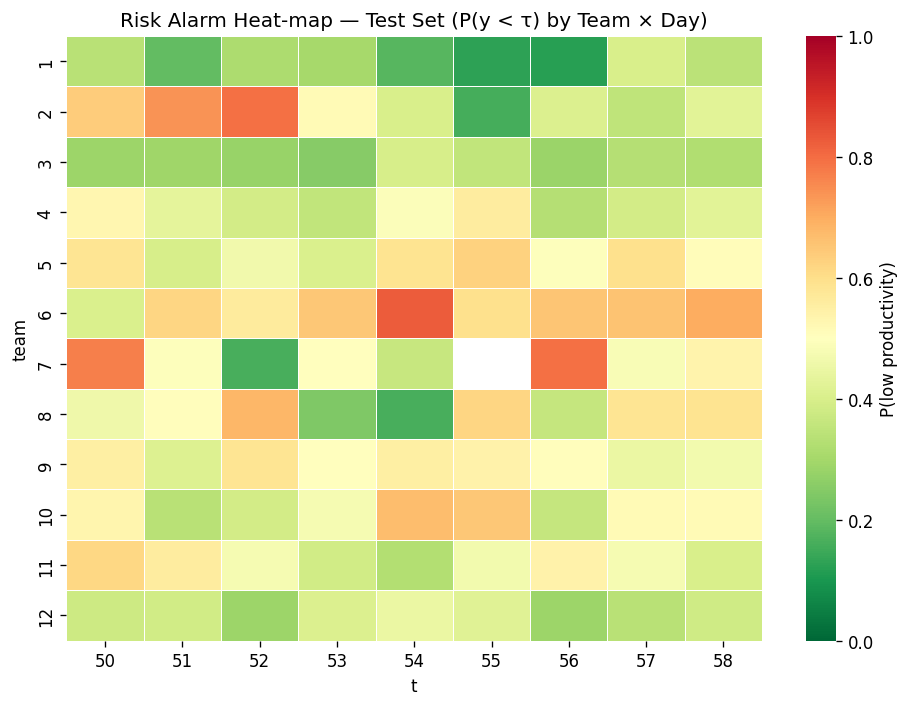

  ✓ Saved: 03_risk_alarm_heatmap.png


In [ ]:
# §8.2  Risk alarm heat-map (test set)
df_test_fc = df_forecasts[df_forecasts["split_code"] == 2].copy()
df_test_fc["alarm"]      = (df_test_fc["p_low"] >= p_star).astype(int)
df_test_fc["low_actual"] = (df_test_fc["actual_y"] < TAU_USED).astype(int)

if len(df_test_fc) > 0:
    pivot  = df_test_fc.pivot_table(index="team", columns="t", values="p_low", aggfunc="mean")
    fig_w  = max(8, len(pivot.columns) // 2)
    fig_h  = max(4, len(TEAMS) // 2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(pivot, ax=ax, cmap="RdYlGn_r", vmin=0, vmax=1,
                linewidths=0.3, linecolor="white",
                cbar_kws={"label": "P(low productivity)"})
    ax.set_title("Risk Alarm Heat-map — Test Set (P(y < τ) by Team × Day)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "03_risk_alarm_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  ✓ Saved: 03_risk_alarm_heatmap.png")
else:
    print("No test rows for risk heatmap.")


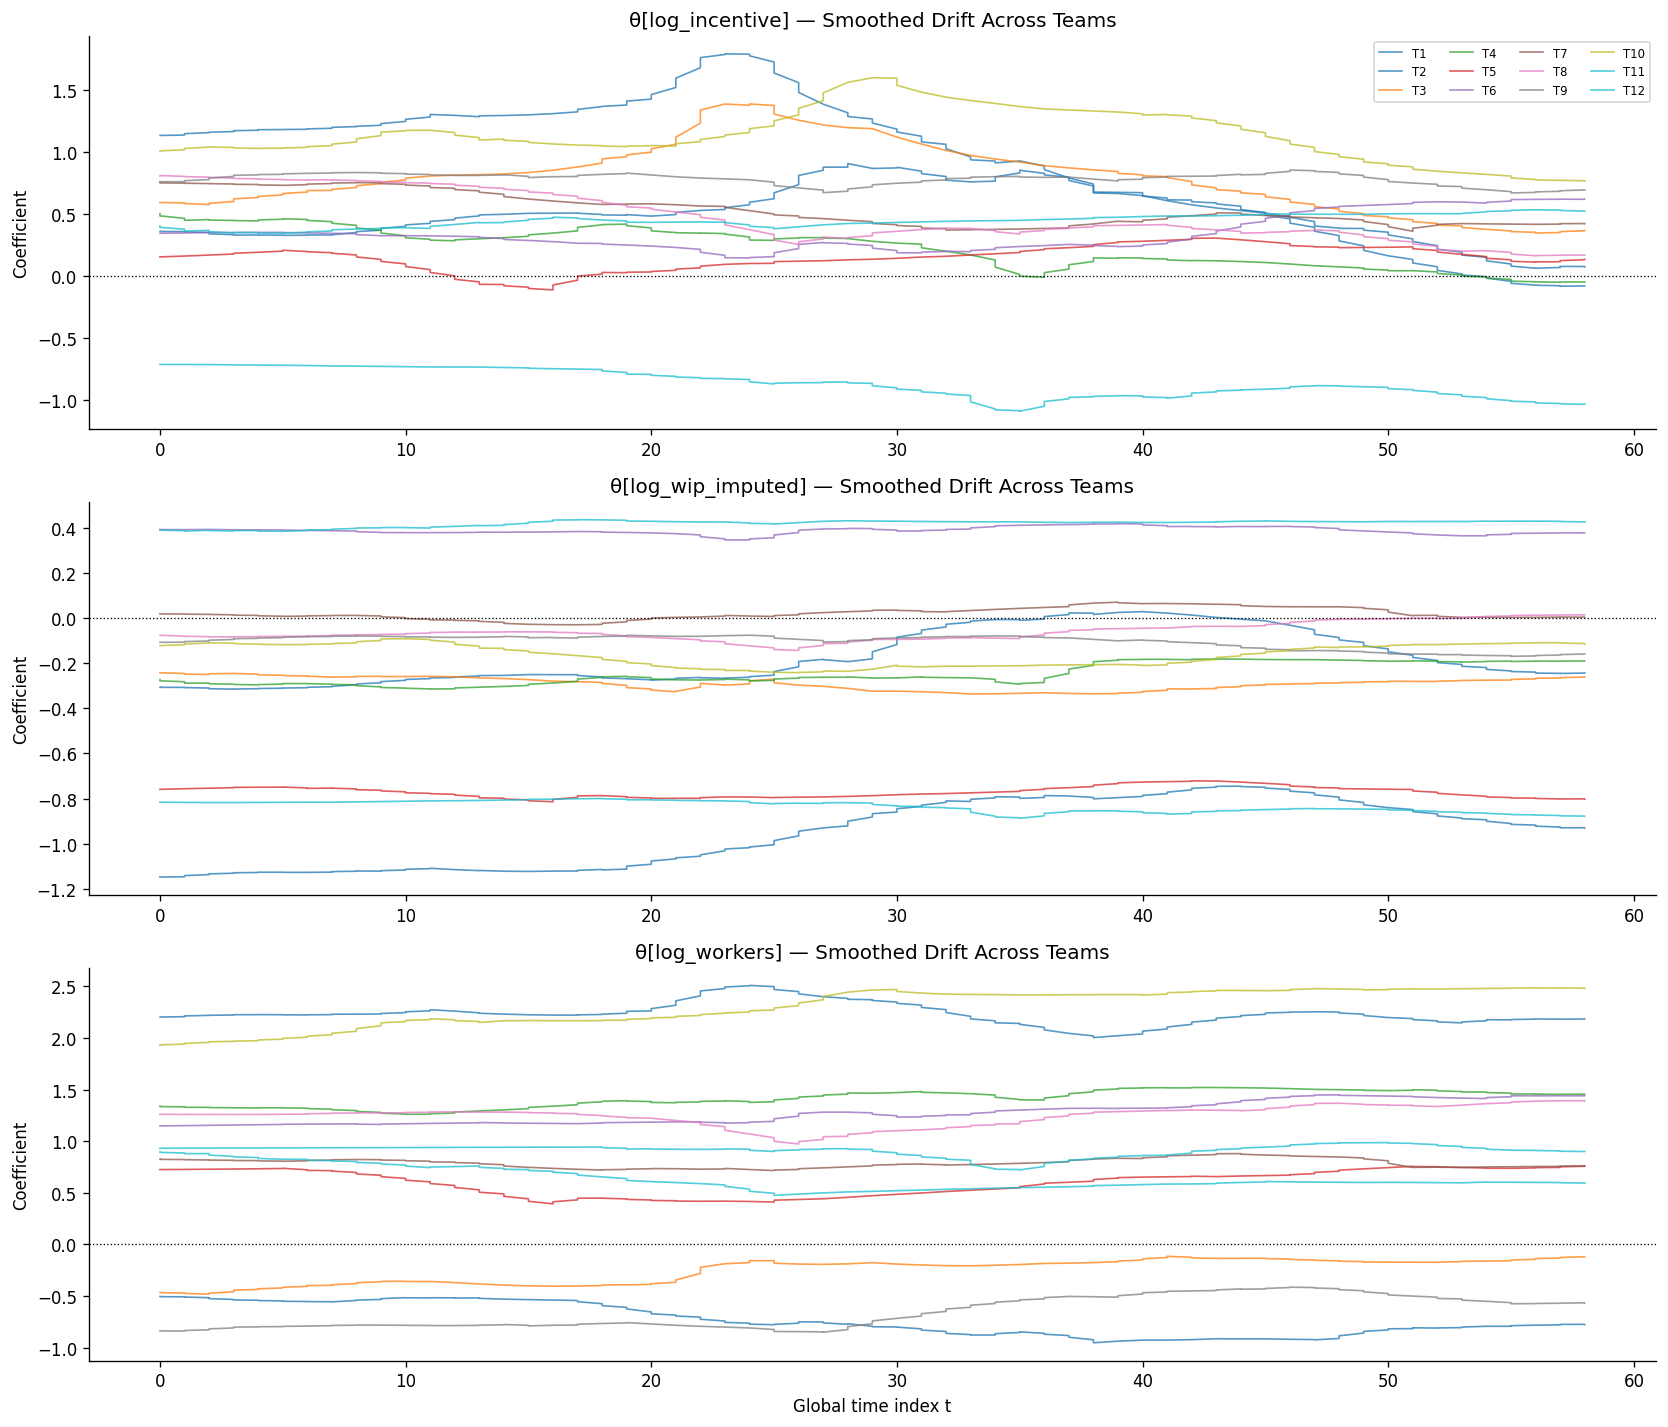

  ✓ Saved: 03_coeff_drift.png


In [ ]:
# §8.3  Coefficient-drift diagnostics
TOP_FEATURES = [f for f in ["log_incentive", "log_wip_imputed", "log_workers"]
                if f in DLM_FEATURES]
# State indices (offset by 1 for intercept column)
TOP_IDX = [DLM_FEATURES.index(f) + 1 for f in TOP_FEATURES]

if TOP_IDX:
    fig, axes = plt.subplots(len(TOP_IDX), 1, figsize=(14, 4*len(TOP_IDX)), sharex=False)
    if len(TOP_IDX) == 1:
        axes = [axes]

    cmap_t = plt.cm.tab10(np.linspace(0, 1, len(TEAMS)))
    for ax_i, feat_i in enumerate(TOP_IDX):
        fname = DLM_FEATURES[feat_i - 1]
        ax    = axes[ax_i]
        for ti, team in enumerate(TEAMS):
            res  = team_results[team]
            df_t = res["df_team"]
            th_s = res["smooth"]["theta_s"][:, feat_i]
            ax.plot(df_t["t"], th_s, color=cmap_t[ti], lw=1, alpha=0.75, label=f"T{team}")
        ax.axhline(0, color="black", ls=":", lw=0.8)
        ax.set_title(f"θ[{fname}] — Smoothed Drift Across Teams")
        ax.set_ylabel("Coefficient")
        if ax_i == 0:
            ax.legend(ncol=4, fontsize=7)
    axes[-1].set_xlabel("Global time index t")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "03_coeff_drift.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  ✓ Saved: 03_coeff_drift.png")


In [ ]:
# §8.4  CUSUM change-point detection
def cusum_changepoints(series, threshold_sigma=3.0):
    diff  = np.diff(np.asarray(series, dtype=float))
    mu    = np.nanmean(diff)
    sigma = np.nanstd(diff)
    if sigma < 1e-10:
        return []
    return list(np.where(np.abs((diff - mu) / sigma) > threshold_sigma)[0] + 1)

print("CUSUM change-points (|Δθ| > 3σ) for first 5 teams:")
for team in TEAMS[:5]:
    res  = team_results[team]
    df_t = res["df_team"]
    for feat_i in TOP_IDX:
        fname = DLM_FEATURES[feat_i - 1]
        th_s  = res["smooth"]["theta_s"][:, feat_i]
        cps   = cusum_changepoints(th_s)
        if cps:
            cp_t = df_t["t"].iloc[cps].tolist()
            print(f"  Team {team:2d}  {fname:22s}: change-points at t={cp_t}")


CUSUM change-points (|Δθ| > 3σ) for first 5 teams:
  Team  1  log_incentive         : change-points at t=[26, 26]
  Team  1  log_wip_imputed       : change-points at t=[29, 30, 30]
  Team  2  log_incentive         : change-points at t=[22]
  Team  3  log_incentive         : change-points at t=[22, 22]
  Team  3  log_wip_imputed       : change-points at t=[22, 22, 25]
  Team  3  log_workers           : change-points at t=[22, 22]
  Team  4  log_incentive         : change-points at t=[34, 35]
  Team  4  log_wip_imputed       : change-points at t=[36, 37, 37, 38]


## §9 · Prescriptive What-If & Uplift Curves

Using **log-transformed** operational levers present in the CSV:  
`log_incentive`, `log_wip_imputed`, `log_workers`


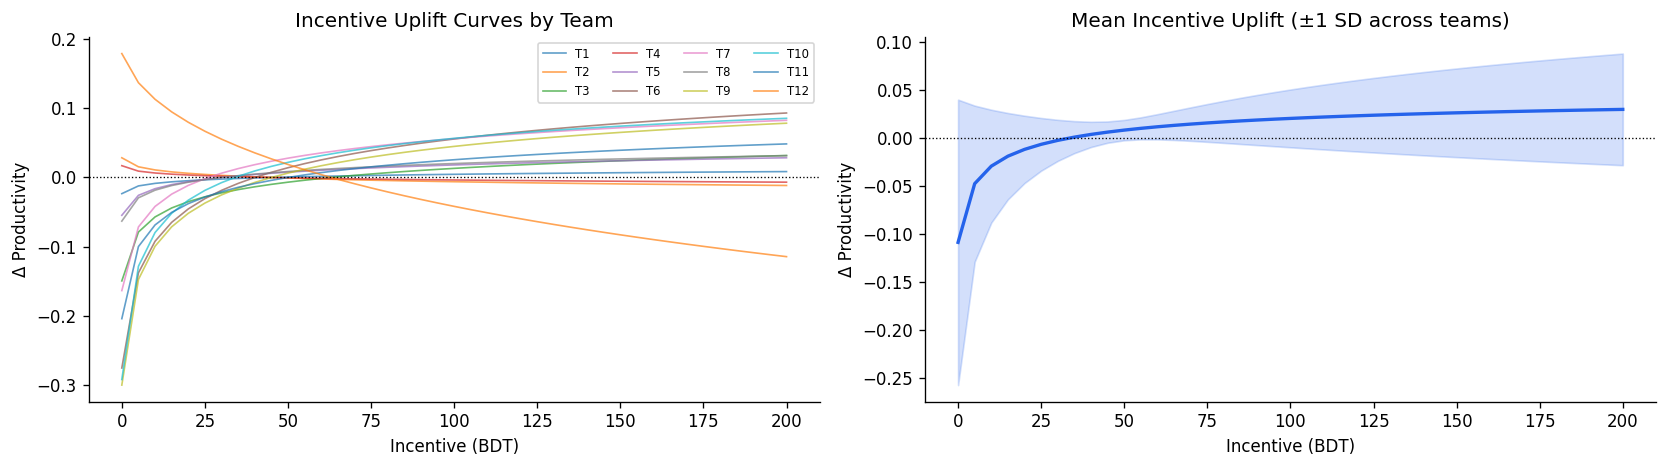

  ✓ Saved: 03_incentive_uplift.png


In [ ]:
# §9.1  Incentive uplift curves (varying log_incentive)
INCENTIVE_GRID_RAW = np.linspace(0, 200, 41)

uplift_records = []
if INC_IDX is None:
    print("⚠  log_incentive not in features — skipping incentive what-if")
else:
    for team in TEAMS:
        res        = team_results[team]
        fr         = res["filter"]
        X_t        = res["X_t"]
        T_last     = len(res["df_team"]) - 1
        theta_last = fr["theta_f"][T_last]
        x_last     = X_t[T_last].copy()
        y_base     = float(inv_logit(float(x_last @ theta_last)))

        for inc_raw in INCENTIVE_GRID_RAW:
            x_cf = x_last.copy()
            log_inc_raw  = np.log1p(inc_raw)
            # INC_IDX already accounts for intercept offset; scaler indices are INC_IDX-1
            x_cf[INC_IDX] = (log_inc_raw - scaler.mean_[INC_IDX - 1]) / max(scaler.scale_[INC_IDX - 1], 1e-8)
            y_cf = float(inv_logit(float(x_cf @ theta_last)))
            uplift_records.append(dict(team=team, incentive=inc_raw,
                                       y_base=y_base, y_cf=y_cf, uplift=y_cf - y_base))

df_uplift = pd.DataFrame(uplift_records)

if len(df_uplift) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    ax = axes[0]
    for ti, team in enumerate(TEAMS):
        sub = df_uplift[df_uplift["team"] == team]
        ax.plot(sub["incentive"], sub["uplift"], lw=1, alpha=0.7, label=f"T{team}")
    ax.axhline(0, color="black", ls=":", lw=0.8)
    ax.set_xlabel("Incentive (BDT)"); ax.set_ylabel("Δ Productivity")
    ax.set_title("Incentive Uplift Curves by Team")
    ax.legend(ncol=4, fontsize=7)

    agg = df_uplift.groupby("incentive")["uplift"].agg(["mean","std"])
    ax2 = axes[1]
    ax2.fill_between(agg.index, agg["mean"]-agg["std"], agg["mean"]+agg["std"],
                     alpha=0.2, color="#2563EB")
    ax2.plot(agg.index, agg["mean"], color="#2563EB", lw=2)
    ax2.axhline(0, color="black", ls=":", lw=0.8)
    ax2.set_xlabel("Incentive (BDT)"); ax2.set_ylabel("Δ Productivity")
    ax2.set_title("Mean Incentive Uplift (±1 SD across teams)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "03_incentive_uplift.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  ✓ Saved: 03_incentive_uplift.png")


In [ ]:
# §9.2  WIP what-if (varying log_wip_imputed)
WIP_GRID_RAW  = np.linspace(0, 3000, 41)
wip_records   = []

if WIP_IDX is None:
    print("⚠  log_wip_imputed not in features — skipping WIP what-if")
else:
    for team in TEAMS:
        res        = team_results[team]
        fr         = res["filter"]
        X_t        = res["X_t"]
        T_last     = len(res["df_team"]) - 1
        theta_last = fr["theta_f"][T_last]
        x_last     = X_t[T_last].copy()
        y_base     = float(inv_logit(float(x_last @ theta_last)))

        for wip_raw in WIP_GRID_RAW:
            x_cf = x_last.copy()
            log_wip = np.log1p(wip_raw)
            x_cf[WIP_IDX] = (log_wip - scaler.mean_[WIP_IDX - 1]) / max(scaler.scale_[WIP_IDX - 1], 1e-8)
            y_cf = float(inv_logit(float(x_cf @ theta_last)))
            wip_records.append(dict(team=team, wip=wip_raw,
                                    y_base=y_base, y_cf=y_cf, uplift=y_cf - y_base))

    df_wip_uplift = pd.DataFrame(wip_records)
    agg_wip = df_wip_uplift.groupby("wip")["uplift"].agg(["mean","std"])

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.fill_between(agg_wip.index, agg_wip["mean"]-agg_wip["std"], agg_wip["mean"]+agg_wip["std"],
                    alpha=0.2, color="#DC2626")
    ax.plot(agg_wip.index, agg_wip["mean"], color="#DC2626", lw=2)
    ax.axhline(0, color="black", ls=":", lw=0.8)
    ax.set_xlabel("WIP (units)"); ax.set_ylabel("Δ Productivity")
    ax.set_title("WIP What-If Curve (mean ±1 SD across teams)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "03_wip_whatif.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  ✓ Saved: 03_wip_whatif.png")
else:
    df_wip_uplift = pd.DataFrame()


SyntaxError: invalid syntax (475542862.py, line 39)

In [ ]:
# §9.3  Budget-constrained incentive allocation (greedy)
if len(df_uplift) > 0:
    BUDGET = 500.0
    STEP   = 5.0

    marginal_lookup = {}
    for team in TEAMS:
        sub = df_uplift[df_uplift["team"] == team].sort_values("incentive")
        marginal_lookup[team] = (sub["incentive"].values, sub["uplift"].values)

    alloc     = {t: 0.0 for t in TEAMS}
    remaining = BUDGET

    while remaining >= STEP:
        gains = {}
        for team in TEAMS:
            inc_arr, up_arr = marginal_lookup[team]
            g_cur  = float(np.interp(alloc[team],        inc_arr, up_arr))
            g_next = float(np.interp(alloc[team] + STEP, inc_arr, up_arr))
            gains[team] = g_next - g_cur
        best_team = max(gains, key=gains.get)
        if gains[best_team] <= 0:
            break
        alloc[best_team] += STEP
        remaining         -= STEP

    print(f"Budget = {BUDGET:.0f} BDT  |  Remaining = {remaining:.0f} BDT")
    print("Optimal incentive allocation:")
    for team in TEAMS:
        print(f"  Team {team:2d}: {alloc[team]:.0f} BDT")
else:
    print("Incentive uplift not computed — budget allocation skipped.")


## §10 · Diagnostic Plots — ROC / PR / Residuals / Calibration

**FIX v3.0:** If `TAU_PROD = 0.75` produces a single class in val+test,  
`TAU_USED` (set in §8.1) is used here instead.


In [ ]:
# §10.1  Prepare val+test frame for diagnostics
df_eval = df_forecasts[df_forecasts["split_code"].isin([1, 2])].copy().dropna(
    subset=["actual_y", "y_pred", "p_low"])

y_true_bin = (df_eval["actual_y"] < TAU_USED).astype(int).values
y_prob     = df_eval["p_low"].values
y_pred     = df_eval["y_pred"].values
y_actual   = df_eval["actual_y"].values

print(f"Eval rows  : {len(df_eval)}")
print(f"Threshold  : τ = {TAU_USED}")
print(f"Low days   : {y_true_bin.sum()} / {len(y_true_bin)} = {y_true_bin.mean():.1%}")

can_classify = (y_true_bin.sum() > 0) and (y_true_bin.sum() < len(y_true_bin))
print(f"Can do ROC/PR: {can_classify}")
if not can_classify:
    print("⚠  Only one class present in val+test — ROC/PR/Calibration will be skipped.")


In [ ]:
# §10.2  ROC curve
if can_classify:
    fpr, tpr, _ = roc_curve(y_true_bin, y_prob)
    auc_roc = roc_auc_score(y_true_bin, y_prob)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, color="#2563EB", lw=2, label=f"DLM (AUC = {auc_roc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve — Low-Day Detection (τ={TAU_USED}, val + test)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "03_roc_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  AUC-ROC = {auc_roc:.4f}")
    print("  ✓ Saved: 03_roc_curve.png")
else:
    print("⚠  Single class — ROC skipped.")


In [ ]:
# §10.3  Precision-Recall curve
if can_classify:
    prec, rec, thresh_pr = precision_recall_curve(y_true_bin, y_prob)
    auc_pr   = average_precision_score(y_true_bin, y_prob)
    baseline = y_true_bin.mean()

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(rec, prec, color="#DC2626", lw=2, label=f"DLM (AP = {auc_pr:.3f})")
    ax.axhline(baseline, color="gray", ls="--", lw=1,
               label=f"No-skill baseline ({baseline:.2f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(f"Precision-Recall Curve — Low-Day Detection (τ={TAU_USED}, val + test)")
    ax.legend()
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "03_pr_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Average Precision = {auc_pr:.4f}")
    print("  ✓ Saved: 03_pr_curve.png")
else:
    print("⚠  Single class — PR curve skipped.")


In [ ]:
# §10.4  Residual diagnostics (4-panel)
residuals = y_actual - y_pred

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
colors = {1: "#F59E0B", 2: "#DC2626"}

ax = axes[0, 0]
for sc, col in colors.items():
    mask = df_eval["split_code"] == sc
    ax.scatter(y_pred[mask], residuals[mask], s=10, alpha=0.4, color=col,
               label=f"{'val' if sc==1 else 'test'}")
ax.axhline(0, color="black", ls="--", lw=1)
ax.set_xlabel("Fitted (y_pred)"); ax.set_ylabel("Residual (actual − pred)")
ax.set_title("A · Residuals vs Fitted"); ax.legend(fontsize=8)

ax = axes[0, 1]
ax.hist(residuals, bins=30, density=True, color="#2563EB", alpha=0.6, edgecolor="white")
xr = np.linspace(residuals.min(), residuals.max(), 200)
ax.plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()),
        color="black", lw=2, label="Normal fit")
ax.set_xlabel("Residual"); ax.set_ylabel("Density")
ax.set_title(f"B · Residual Distribution  (μ={residuals.mean():.4f}, σ={residuals.std():.4f})")
ax.legend()

ax = axes[1, 0]
(osm, osr), (slope, intercept_qq, r) = stats.probplot(residuals, dist="norm")
ax.scatter(osm, osr, s=8, alpha=0.4, color="#2563EB")
ax.plot(osm, slope * np.array(osm) + intercept_qq, color="red", lw=1.5)
ax.set_xlabel("Theoretical Quantiles"); ax.set_ylabel("Sample Quantiles")
ax.set_title(f"C · Normal Q-Q Plot  (R²={r**2:.4f})")

ax = axes[1, 1]
for sc, col in colors.items():
    mask = df_eval["split_code"] == sc
    ax.scatter(df_eval["t"].values[mask], residuals[mask],
               s=10, alpha=0.4, color=col,
               label=f"{'val' if sc==1 else 'test'}")
ax.axhline(0, color="black", ls="--", lw=1)
ax.set_xlabel("Global time index t"); ax.set_ylabel("Residual")
ax.set_title("D · Residuals vs Time (drift check)"); ax.legend(fontsize=8)

plt.suptitle("Residual Diagnostics — Kalman DLM (val + test)", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "03_residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Saved: 03_residual_diagnostics.png")


In [ ]:
# §10.5  Calibration curve
if can_classify:
    frac_pos, mean_pred = calibration_curve(y_true_bin, y_prob, n_bins=10)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    ax = axes[0]
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
    ax.plot(mean_pred, frac_pos, "o-", color="#2563EB", lw=2, ms=6, label="DLM")
    ax.set_xlabel("Mean predicted probability P(low)"); ax.set_ylabel("Fraction of low days")
    ax.set_title("Calibration Curve — P(low-day)")
    ax.legend(); ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    ax2 = axes[1]
    ax2.hist(y_prob[y_true_bin == 0], bins=20, alpha=0.6, color="#22C55E",
             density=True, label="Not-low days")
    ax2.hist(y_prob[y_true_bin == 1], bins=20, alpha=0.6, color="#DC2626",
             density=True, label="Low days")
    ax2.axvline(p_star, color="black", ls="--", lw=1.5, label=f"p*={p_star:.2f}")
    ax2.set_xlabel("P(low-day)"); ax2.set_ylabel("Density")
    ax2.set_title("Score Distribution by Class"); ax2.legend()

    plt.suptitle("Calibration Diagnostics — Kalman DLM", fontsize=13)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "03_calibration.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  ✓ Saved: 03_calibration.png")
else:
    print("⚠  Single class — calibration skipped.")


In [ ]:
# §10.6  4-panel Summary Dashboard (test set)
df_test_dash = df_forecasts[df_forecasts["split_code"] == 2].dropna(
    subset=["actual_y", "y_pred"])

fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

ax0 = fig.add_subplot(gs[0, 0])
if len(df_test_dash) > 0:
    y_t = df_test_dash["actual_y"].values
    y_p = df_test_dash["y_pred"].values
    mn, mx = min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())
    ax0.scatter(y_t, y_p, s=14, alpha=0.4, color="steelblue")
    ax0.plot([mn, mx], [mn, mx], "r--", lw=1.2)
    mae_t  = mean_absolute_error(y_t, y_p)
    rmse_t = np.sqrt(mean_squared_error(y_t, y_p))
    r2_t   = r2_score(y_t, y_p)
    ax0.set_xlabel("Actual"); ax0.set_ylabel("Predicted")
    ax0.set_title(f"A · Forecast vs Actual\nMAE={mae_t:.4f}  RMSE={rmse_t:.4f}  R²={r2_t:.4f}")

ax1 = fig.add_subplot(gs[0, 1])
team_mae = (df_test_dash.groupby("team")
            .apply(lambda g: mean_absolute_error(g["actual_y"], g["y_pred"]))
            .reset_index(name="mae"))
ax1.bar(team_mae["team"].astype(str), team_mae["mae"], color="#2563EB", alpha=0.8)
ax1.set_xlabel("Team"); ax1.set_ylabel("MAE")
ax1.set_title("B · MAE by Team (test set)")

ax2 = fig.add_subplot(gs[1, 0])
cov80 = ((df_test_dash["actual_y"] >= df_test_dash["y_lo80"]) &
         (df_test_dash["actual_y"] <= df_test_dash["y_hi80"])).mean()
cov95 = ((df_test_dash["actual_y"] >= df_test_dash["y_lo95"]) &
         (df_test_dash["actual_y"] <= df_test_dash["y_hi95"])).mean()
ax2.bar(["80% PI", "95% PI"], [cov80, cov95], color=["#F59E0B", "#2563EB"])
ax2.axhline(0.80, color="orange", ls="--", lw=1.2, label="Target 80%")
ax2.axhline(0.95, color="blue",   ls="--", lw=1.2, label="Target 95%")
ax2.set_ylim(0, 1.05); ax2.set_ylabel("Coverage rate")
ax2.set_title(f"C · PI Coverage  (80%={cov80:.1%}, 95%={cov95:.1%})")
ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[1, 1])
if can_classify and len(df_test_dash) > 0:
    low_mask = df_test_dash["actual_y"] < TAU_USED
    ax3.hist(df_test_dash.loc[~low_mask, "p_low"], bins=20, alpha=0.6,
             color="#22C55E", density=True, label="Not-low")
    ax3.hist(df_test_dash.loc[low_mask,  "p_low"], bins=20, alpha=0.6,
             color="#DC2626", density=True, label="Low")
    ax3.axvline(p_star, color="black", ls="--", lw=1.5, label=f"p*={p_star:.2f}")
    ax3.set_xlabel("P(low day)"); ax3.set_ylabel("Density")
    ax3.set_title("D · Risk Score Distribution (test set)"); ax3.legend()

plt.suptitle("DLM Summary Dashboard — Test Set", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "03_summary_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✓ Saved: 03_summary_dashboard.png")


## §11 · Validation & Comparison Table

**v3.0 metrics additions:**  
- **sMAPE** replaces raw MAPE  
- **R²_postburn** — train R² with first `BURNIN_STEPS` rows per team removed (removes cold-start bias)  
- **R²_smoother** — in-sample upper bound from RTS smoother (shown separately)


In [ ]:
# §11.1  Forecast accuracy metrics by split
metrics    = {}
split_map  = {0: "train", 1: "val", 2: "test"}

print(f"{'Split':>6}  {'N':>5}  {'MAE':>8}  {'RMSE':>8}  {'sMAPE%':>8}  "
      f"{'R²':>8}  {'R²_postburn':>12}  {'Cov80':>7}  {'Cov95':>7}  {'AUC-ROC':>9}  {'AP':>8}")
print("-" * 115)

for code_s, sname in sorted(split_map.items()):
    sub = df_forecasts[df_forecasts["split_code"] == code_s].dropna(
        subset=["actual_y", "y_pred"])
    if len(sub) == 0:
        continue

    y_t = sub["actual_y"].values
    y_p = sub["y_pred"].values
    mae   = mean_absolute_error(y_t, y_p)
    rmse  = np.sqrt(mean_squared_error(y_t, y_p))
    r2    = r2_score(y_t, y_p)
    smap  = smape(y_t, y_p)
    cov80 = ((y_t >= sub["y_lo80"].values) & (y_t <= sub["y_hi80"].values)).mean()
    cov95 = ((y_t >= sub["y_lo95"].values) & (y_t <= sub["y_hi95"].values)).mean()

    # Post-burnin R² (train only)
    if code_s == 0 and "burnin" in sub.columns:
        sub_pb = sub[~sub["burnin"]]
        r2_pb  = r2_score(sub_pb["actual_y"], sub_pb["y_pred"]) if len(sub_pb) > 1 else float("nan")
    else:
        r2_pb  = r2

    y_bin = (y_t < TAU_USED).astype(int)
    if y_bin.sum() > 0 and y_bin.sum() < len(y_bin):
        auc = roc_auc_score(y_bin, sub["p_low"].values)
        ap  = average_precision_score(y_bin, sub["p_low"].values)
    else:
        auc = ap = float("nan")

    metrics[sname] = dict(N=len(sub), MAE=mae, RMSE=rmse, sMAPE=smap,
                          R2=r2, R2_postburn=r2_pb,
                          Cov80=cov80, Cov95=cov95, AUC_ROC=auc, AP=ap)
    print(f"{sname:>6}  {len(sub):>5}  {mae:>8.5f}  {rmse:>8.5f}  {smap:>8.2f}  "
          f"{r2:>8.4f}  {r2_pb:>12.4f}  {cov80:>7.3f}  {cov95:>7.3f}  {auc:>9.4f}  {ap:>8.4f}")

print()
print("Notes:")
print(f"  - Train R² uses cold-start prior → expected to be low or negative.")
print(f"  - R²_postburn excludes first {BURNIN_STEPS} steps per team from train (removes cold-start bias).")
print(f"  - Val/Test R² is the meaningful out-of-sample quality indicator.")
print(f"  - Smoother in-sample train: MAE={mae_s:.5f}  RMSE={rmse_s:.5f}  R²={r2_s:.4f}  (upper bound)")


In [ ]:
# §11.2  Comparison table vs. paper benchmarks
# FIX v3.0: None → 'N/A' for display; added sMAPE column
test_m = metrics.get("test",  {})
val_m  = metrics.get("val",   {})
tr_m   = metrics.get("train", {})

def fmt(v, decimals=5):
    """Format float or return N/A."""
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return "N/A"
    return f"{v:.{decimals}f}"

rows = [
    dict(Model="Paper GBT+SMOTE (2-class)",    Split="test",
         MAE="N/A", RMSE="N/A", sMAPE="N/A", R2="N/A",
         AUC_ROC="0.90700", AP="N/A", Cov95="N/A", Note="Al Imran et al. 2021"),
    dict(Model="Paper Tree Ensemble (3-class)", Split="test",
         MAE="N/A", RMSE="N/A", sMAPE="N/A", R2="N/A",
         AUC_ROC="0.86100", AP="N/A", Cov95="N/A", Note="Al Imran et al. 2021"),
    dict(Model="Kalman DLM", Split="train",
         MAE=fmt(tr_m.get("MAE")), RMSE=fmt(tr_m.get("RMSE")),
         sMAPE=fmt(tr_m.get("sMAPE"), 2), R2=fmt(tr_m.get("R2"), 4),
         AUC_ROC=fmt(tr_m.get("AUC_ROC"), 4), AP=fmt(tr_m.get("AP"), 4),
         Cov95=fmt(tr_m.get("Cov95"), 3), Note="this notebook (cold-start R²)"),
    dict(Model="Kalman DLM", Split="val",
         MAE=fmt(val_m.get("MAE")), RMSE=fmt(val_m.get("RMSE")),
         sMAPE=fmt(val_m.get("sMAPE"), 2), R2=fmt(val_m.get("R2"), 4),
         AUC_ROC=fmt(val_m.get("AUC_ROC"), 4), AP=fmt(val_m.get("AP"), 4),
         Cov95=fmt(val_m.get("Cov95"), 3), Note="this notebook"),
    dict(Model="Kalman DLM", Split="test",
         MAE=fmt(test_m.get("MAE")), RMSE=fmt(test_m.get("RMSE")),
         sMAPE=fmt(test_m.get("sMAPE"), 2), R2=fmt(test_m.get("R2"), 4),
         AUC_ROC=fmt(test_m.get("AUC_ROC"), 4), AP=fmt(test_m.get("AP"), 4),
         Cov95=fmt(test_m.get("Cov95"), 3), Note="this notebook"),
]

comparison = pd.DataFrame(rows)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)
print(comparison.to_string(index=False))


## §12 · Save All Results & Push to GitHub

In [ ]:
# §12.1  Save CSVs to models/ folder
df_risk = df_forecasts[["team","date","t","split_code","actual_y","y_pred","p_low"]].copy()
df_risk["alarm"]      = (df_risk["p_low"] >= p_star).astype(int)
df_risk["low_actual"] = (df_risk["actual_y"] < TAU_USED).astype(int)

csv_outputs = {
    "03_dlm_forecasts.csv":        df_forecasts,
    "03_dlm_filtered_states.csv":  df_states,
    "03_dlm_risk_alarms.csv":      df_risk,
    "03_dlm_comparison.csv":       comparison,
}
if len(df_uplift) > 0:
    csv_outputs["03_dlm_incentive_uplift.csv"] = df_uplift
if len(df_wip_uplift) > 0:
    csv_outputs["03_dlm_wip_uplift.csv"] = df_wip_uplift

for fname, df_out in csv_outputs.items():
    path = SAVE_DIR / fname
    df_out.to_csv(path, index=False)
    print(f"  ✓ Saved CSV: {path.name}")


In [ ]:
# §12.2  Save pickle
dlm_results = dict(
    Q_em=Q_em, R_em=R_em, Q_best=Q_best,
    best_delta=best_delta, delta_results=delta_results,
    em_n_iter=em_result["n_iter_run"],
    DLM_FEATURES=DLM_FEATURES, p=p, scaler=scaler,
    TAU_PROD=TAU_PROD, TAU_USED=TAU_USED,
    p_star=p_star, metrics=metrics,
    df_forecasts=df_forecasts, df_states=df_states,
    comparison=comparison,
)

pkl_path = SAVE_DIR / "dlm_results.pkl"
with open(pkl_path, "wb") as f:
    pickle.dump(dlm_results, f)
print(f"  ✓ Saved pickle: {pkl_path.name}")

def _to_py(obj):
    if isinstance(obj, dict):   return {k: _to_py(v) for k, v in obj.items()}
    if isinstance(obj, (np.float32, np.float64)): return float(obj)
    if isinstance(obj, (np.int32, np.int64)):     return int(obj)
    if isinstance(obj, np.ndarray):               return obj.tolist()
    return obj

json_summary = {k: v for k, v in dlm_results.items()
                if not isinstance(v, (pd.DataFrame, np.ndarray, StandardScaler))}
json_path = SAVE_DIR / "dlm_summary.json"
with open(json_path, "w") as f:
    json.dump(_to_py(json_summary), f, indent=2, default=str)
print(f"  ✓ Saved JSON : {json_path.name}")


In [ ]:
# §12.3  List all saved output PNGs
png_files = list(OUT_DIR.glob("03_*.png"))
print(f"\nOutput PNGs in {OUT_DIR}:")
for p_file in sorted(png_files):
    size_kb = p_file.stat().st_size / 1024
    print(f"  {p_file.name:45s}  {size_kb:6.1f} KB")


In [ ]:
# §12.4  Git commit & push (Colab only)
if IN_COLAB:
    import subprocess
    os.chdir(REPO_DIR)
    ts  = datetime.now().strftime("%Y-%m-%d %H:%M")
    msg = f"Add Kalman DLM outputs (v3.0) — {ts}"
    cmds = [
        "git config user.email 'colab@notebook.ci'",
        "git config user.name 'Colab Notebook'",
        "git add output/03_*.png models/03_*.csv models/dlm_results.pkl models/dlm_summary.json",
        f'git commit -m "{msg}" || echo "Nothing to commit"',
        "git push",
    ]
    for cmd in cmds:
        result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
        print(result.stdout.strip() or result.stderr.strip())
    print("\n✓ Outputs pushed to GitHub")
else:
    print("Local mode — skipping git push. Run manually from:", REPO_DIR)


In [ ]:
# §12.5  Final summary banner
print("\n" + "═" * 72)
print(" DLM PIPELINE COMPLETE (v3.0) ".center(72, "═"))
print("═" * 72)
print(f"  CSV loaded          : bayesian_glm_ready.csv")
print(f"  Teams processed     : {len(TEAMS)}")
print(f"  Features (p)        : {p}  (1 intercept + {len(DLM_FEATURES)} covariates)")
print(f"  EM iterations       : {em_result['n_iter_run']}")
print(f"  Best delta (δ)      : {best_delta}")
print(f"  Q trace (EM)        : {np.trace(Q_em):.6f}")
print(f"  R (obs noise)       : {R_em:.5f}")
print(f"  Alarm threshold p*  : {p_star:.3f}  (τ used = {TAU_USED})")
print(f"  Burn-in steps       : {BURNIN_STEPS} per team excluded from train R²")
if "test" in metrics:
    tm = metrics["test"]
    print(f"  ── Test set (one-step-ahead, warm-started) ──")
    print(f"  MAE                 : {tm.get('MAE', float('nan')):.5f}")
    print(f"  RMSE                : {tm.get('RMSE', float('nan')):.5f}")
    print(f"  sMAPE               : {tm.get('sMAPE', float('nan')):.2f}%")
    print(f"  R²                  : {tm.get('R2', float('nan')):.4f}")
    print(f"  80% PI coverage     : {tm.get('Cov80', float('nan')):.3f}")
    print(f"  95% PI coverage     : {tm.get('Cov95', float('nan')):.3f}")
    print(f"  AUC-ROC             : {tm.get('AUC_ROC', float('nan')):.4f}")
    print(f"  Average Precision   : {tm.get('AP', float('nan')):.4f}")
if "val" in metrics:
    vm = metrics["val"]
    print(f"  ── Val set ──")
    print(f"  MAE                 : {vm.get('MAE', float('nan')):.5f}")
    print(f"  RMSE                : {vm.get('RMSE', float('nan')):.5f}")
    print(f"  R²                  : {vm.get('R2', float('nan')):.4f}")
print(f"  ── Smoother in-sample (upper bound) ──")
print(f"  MAE                 : {mae_s:.5f}")
print(f"  RMSE                : {rmse_s:.5f}")
print(f"  R²                  : {r2_s:.4f}")
print("═" * 72)
print("\nAll rolling metrics are in probability space [0,1].")
print(f"Train R² is biased low due to cold-start; post-burnin R² is reported separately.")
print("Val/Test R² is the true out-of-sample quality metric.")
print("Smoother R² is the in-sample upper bound (not predictive).")
